# MFE 230X — High-Frequency Finance — Homework 1

**NASDAQ TotalView-ITCH (Databento) and the two supplied Currency files**

Instructors: Terrence Hendershott, Dmitry Livdan · Fall 2026  
Authors: Alexandre Marthan · Elias Roubache · Jean Jacob · Matthieu Pascal · Elouan Bahri

| Market | Instruments | Sample session |
|---|---|---|
| NASDAQ | AAPL (large cap), GPRO (small cap) | 2019-12-30, 09:30–16:00 ET |
| Currency | EUR/USD, USD/JPY, EUR/JPY | 2012-01-25, 09:30–16:00 (file timestamps) |

The stock and currency dates differ because Homework 1 asks for Databento on the equity side and the two course Data Folder files on the currency side. This notebook does not substitute another FX vendor.

This is the single canonical notebook for the submission. The data pipeline is inlined below (so the file can be uploaded to Datalore on its own) and is kept identical to `src/hw1_pipeline.py` in the repository; a check cell confirms the two match when the repository copy is present.

**Why these two stocks.** The assignment asks for two NASDAQ names that differ in market capitalization. AAPL is a large-cap, high-turnover name; GPRO (GoPro) is a small-cap name trading near $4.30 on this day. The point of the pair is not that we screened a universe — it is that the same book-construction and impact code can be read against a thick name and a thin, tick-constrained name. If adverse-selection costs scale with how easily a dealer averages informed flow against noise trades, the two books should not look alike. Currency pairs are the assigned EUR triangle, not a choice.


## Methodology fixed before looking at the results

- **Stocks:** MBP-10 supplies trades and the top ten price levels; MBO supplies strict new-order counts. Databento timestamps are converted from UTC to New York and all work uses exchange-event time (`ts_event`). The 10-minute pre-open MBP-10 buffer seeds the 09:30 book.
- **Orders:** `n_orders` counts genuine ITCH additions. Databento represents a replace as a `C+A` pair with the same symbol, channel and sequence; the replacement-generated `A` is excluded. The raw number of `A` messages is retained as a diagnostic. ITCH (and therefore Databento MBO) carries **displayed** orders only: hidden liquidity shows up in the trade stream but never as an add message, so `n_orders` is a count of visible orders. This is the FAQ's `ORDER_ID = 0` case, handled here by construction rather than by subtracting one.
- **Currency:** each physical CSV row may contain one, two or three pair blocks. Each populated block is converted to a long event. In the order file, flag 0 is bid, flag 1 is ask, `SIZE` replaces the entire level quantity, and zero removes the level. Integer price ticks are used as book keys.
- **Trades and dollars:** stock notional is `price × size`. Currency uses `TOTAL_SIZE` as the complete transaction quantity: EUR/USD is already USD notional; USD/JPY size is USD; EUR/JPY JPY notional is converted with the same-second USD/JPY midpoint. Currency flag 0 maps to trade sign −1 and flag 1 to +1. Databento sides `A/B` map to −1/+1; unsigned `N` trades remain in volume/OHLC/VWAP but are omitted from signed-impact regressions.
- **Liquidity:** spread and bid/ask depth are piecewise-constant and averaged with exact event-time weights in each minute. These are **exchange BBO** numbers from NASDAQ TotalView, not the NBBO. A protected National Best Bid/Offer can be better than NASDAQ alone; we do not have the other venues. Depth at twice the daily average spread sums bid size at prices ≥ `mid − 2×avg spread` and ask size at prices ≤ `mid + 2×avg spread`, each side separately. That band is the size you can lift or hit before walking more than two typical spreads. The assignment notes it is zero when the quoted spread itself exceeds twice the daily average. `DEPTH_BAND_MULTIPLIER` can be changed if the instructors issue a different convention.
- **5-second impact:** within every minute, regress `(mid(t+5s) − mid(t))/mid(t)` on a constant and the current trade sign. For Databento, `mid(t)` is the pre-trade BBO carried on the `T` record. Otherwise it is the latest book state strictly before the trade; `mid(t+5s)` is the latest state at or before the horizon. A minute is left blank when there are not enough signed trades to identify the slope. **What the matching choice means:** taking the quote strictly *before* the trade avoids look-ahead (the trade itself may move the book), at the cost of ignoring any quote update between the trade and the next book message; taking the *last* state at or before `t+5s` rather than the next one means that in a thin name (GPRO, EUR/JPY) the "5-second" midpoint can be a quote that is several seconds stale, which biases the measured impact toward zero exactly where trading is sparsest. The same regression is also run pooled over the day and split by dollar-size tercile, to test the Discussion 2 claim that larger trades are more informed.
- **Prices and returns:** the last midpoint and transaction price in each 1-second/1-minute interval are used, with previous-tick carry-forward after the first valid observation. A bar with no print therefore carries the previous trade forward and its transaction return is an exact zero by construction; every such bar is flagged (`trade_is_stale`) and the return diagnostics are reported both on the full grid and on the trade-to-trade series that drops those bars. Returns are log differences. Two variance measures appear and are labelled separately: *realized variance* is the sum of squared intraday returns Σr² (part j); the 30-minute figure and table use the *sample variance* of the 1-minute returns inside each window. Autocorrelations are reported at lags 1–10 in the figure (lag 0 equals 1 by construction and is dropped from the plot, as suggested in the discussion session).
- **Triangular arbitrage:** both executable bid/ask loops are tested on synchronized one-second books. A second is counted only if every leg has a strictly positive, uncrossed BBO (`ask > bid > 0`). Frequency, consecutive duration, binding BBO quantity (EUR), and frictionless marked profit are reported. Because the three books are sampled independently at the end of each second, a loop return smaller than one tick of the coarsest leg (USD/JPY, 0.001) is within the rounding of the three price grids; the raw screen is kept as the primary count, and the seconds that clear one tick and one full EUR/USD pip are reported alongside. The execution cost of being late is measured directly: every flagged second is re-priced at the executable quotes 1, 2, 3 and 5 seconds later. Latency to the venue, fees, and whether the quotes were firm are not in these files.
- **Timing:** every load and analysis block is timed with `time.perf_counter`. The final table also reports, for each step, how many seconds of tape it processed per second of compute and the microseconds spent per one-second bar, and the arbitrage detector is additionally run one second at a time with the wall clock read around every decision. The last section compares those numbers with how long an apparent arbitrage actually lasts and with how fast its profit decays once it is acted on late.
- **Missing trades as liquidity:** for each minute we also count the seconds with no print and the longest print-free gap. Trade arrival is the flip side of depth: a quote nobody hits is untested, and the share of empty bars is the standard zero-return illiquidity proxy (Lesmond–Ogden–Trzcinka). It is also exactly what contaminates the 1-second transaction-return series, so the two uses are reported together.
- **Intraday activity:** trades, dollar volume and (stocks) orders are compared across the first 30 minutes, 12:00–13:30 and the last 30 minutes relative to the rest of the day, and plotted per 5-minute bin normalised by the day mean, to test the U-shape claim directly rather than infer it from variance.


In [1]:
import importlib.util
import subprocess
import sys

required = {
    "databento": "databento",
    "matplotlib": "matplotlib",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

from pathlib import Path
import time
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.style.use("seaborn-v0_8-whitegrid")


## Data pipeline

The following cell is deliberately self-contained so the notebook can be uploaded to Datalore without a separate local Python module. It is a verbatim copy of `src/hw1_pipeline.py`; the check cell after it confirms that when the repository copy is present. DBN files are streamed in chunks; the compressed files do not need to be unzipped.


In [2]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import time

import numpy as np
import pandas as pd


TZ = "America/New_York"
SESSION_START = "09:30:00"
SESSION_END = "16:00:00"
STOCKS = ["AAPL", "GPRO"]
FX_PAIRS = ["EURUSD", "USDJPY", "EURJPY"]
FX_PRICE_SCALE = {"EURUSD": 100_000, "USDJPY": 1_000, "EURJPY": 1_000}
# Discussion Session 02, slide "Depth at twice average spread":
# ask prices <= midquote + 2*average spread, symmetrically for bids.
DEPTH_BAND_MULTIPLIER = 2.0
TIMINGS: dict[str, float] = {}


def time_block(name: str):
    """Record wall-clock seconds for a named load or analysis step in TIMINGS."""

    class _Timer:
        def __enter__(self) -> None:
            self._start = time.perf_counter()

        def __exit__(self, exc_type, exc, tb) -> None:
            TIMINGS[name] = time.perf_counter() - self._start

    return _Timer()


def session_bounds(date: str) -> tuple[pd.Timestamp, pd.Timestamp]:
    """Return the regular-session [09:30, 16:00) timestamps for ``date``."""
    return (
        pd.Timestamp(f"{date} {SESSION_START}").as_unit("ns"),
        pd.Timestamp(f"{date} {SESSION_END}").as_unit("ns"),
    )


def session_grid(date: str, freq: str) -> pd.DatetimeIndex:
    """Build a left-closed regular-session grid at the requested frequency."""
    start, end = session_bounds(date)
    return pd.date_range(start, end, freq=freq, inclusive="left", unit="ns")


def _state_events_for_session(
    events: pd.DataFrame, date: str, fields: list[str]
) -> pd.DataFrame:
    """Return state-change rows clipped to the session, including a 09:30 seed."""
    start, end = session_bounds(date)
    state = events[fields].sort_index(kind="stable")
    state = state[~state.index.duplicated(keep="last")]
    seed = state.loc[state.index <= start].tail(1).copy()
    if seed.empty:
        if state.loc[(state.index > start) & (state.index < end)].empty:
            return state.iloc[0:0]
        seed = pd.DataFrame([[np.nan] * len(fields)], index=[start], columns=fields)
    else:
        seed.index = pd.DatetimeIndex([start])
    inside = state.loc[(state.index > start) & (state.index < end)]
    return pd.concat([seed, inside]).sort_index(kind="stable")


def _time_weighted_average(
    events: pd.DataFrame, field: str, date: str
) -> float:
    """Session-wide time-weighted mean of a piecewise-constant quote field."""
    state = _state_events_for_session(events, date, [field])
    if state.empty:
        return np.nan
    _, end = session_bounds(date)
    boundaries = state.index.to_numpy(dtype="datetime64[ns]").astype("int64")
    next_boundaries = np.r_[boundaries[1:], end.value]
    duration_s = (next_boundaries - boundaries) / 1e9
    values = state[field].to_numpy(dtype=float)
    valid = np.isfinite(values) & (duration_s > 0)
    return float(np.average(values[valid], weights=duration_s[valid])) if valid.any() else np.nan


def _time_weighted_minute(
    events: pd.DataFrame, fields: list[str], date: str
) -> pd.DataFrame:
    """Integrate piecewise-constant state exactly over each one-minute bin."""
    state = _state_events_for_session(events, date, fields)
    minute_index = session_grid(date, "1min")
    result = pd.DataFrame(np.nan, index=minute_index, columns=fields, dtype=float)
    if state.empty:
        return result

    start, end = session_bounds(date)
    event_ns = state.index.as_unit("ns").asi8
    end_ns = end.value
    next_ns = np.r_[event_ns[1:], end_ns]
    values = state[fields].to_numpy(dtype=float)
    valid = np.isfinite(values)
    segment_ns = (next_ns - event_ns)[:, None]
    cumulative = np.vstack([
        np.zeros(len(fields)),
        np.cumsum(np.where(valid, values, 0.0) * segment_ns, axis=0),
    ])
    valid_cumulative = np.vstack([
        np.zeros(len(fields)),
        np.cumsum(valid.astype(float) * segment_ns, axis=0),
    ])

    boundary_ns = pd.date_range(start, end, freq="1min", unit="ns").asi8
    positions = np.searchsorted(event_ns, boundary_ns, side="right") - 1
    area = np.empty((len(boundary_ns), len(fields)), dtype=float)
    valid_area = np.empty((len(boundary_ns), len(fields)), dtype=float)
    for i, (boundary, pos) in enumerate(zip(boundary_ns, positions)):
        if pos < 0:
            area[i] = np.nan
            valid_area[i] = np.nan
        elif pos >= len(event_ns):
            area[i] = cumulative[-1]
            valid_area[i] = valid_cumulative[-1]
        else:
            partial = boundary - event_ns[pos]
            area[i] = cumulative[pos] + np.where(valid[pos], values[pos], 0.0) * partial
            valid_area[i] = valid_cumulative[pos] + valid[pos].astype(float) * partial
    numerator = np.diff(area, axis=0)
    denominator = np.diff(valid_area, axis=0)
    result.loc[:, fields] = np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan),
        where=denominator > 0,
    )
    return result


def _local_event_index(frame: pd.DataFrame) -> pd.DataFrame:
    """Use exchange-event time, convert UTC to New York, and remove the timezone."""
    out = frame.copy()
    if "ts_event" not in out.columns:
        raise KeyError("Databento frame does not contain ts_event")
    idx = pd.DatetimeIndex(pd.to_datetime(out["ts_event"], utc=True))
    out.index = idx.tz_convert(TZ).tz_localize(None).as_unit("ns")
    out.index.name = "ts"
    return out


def _dbn_frame_iterator(path: str | Path, chunk_records: int = 250_000):
    import databento as db

    store = db.DBNStore.from_file(path)
    frames = store.to_df(
        price_type="float",
        pretty_ts=True,
        map_symbols=True,
        count=chunk_records,
    )
    yield from frames


def _finish_databento_book(
    quote_parts: list[pd.DataFrame],
    date: str,
    avg_spread: float,
    band_multiplier: float = DEPTH_BAND_MULTIPLIER,
) -> pd.DataFrame:
    """Build a 1-second NASDAQ book, BBO stats, and 2×-spread band depth."""
    if not quote_parts:
        return pd.DataFrame(index=session_grid(date, "1s"))

    q = pd.concat(quote_parts).sort_index(kind="stable")
    q = q.groupby(q.index.floor("1s"), sort=True).tail(1)
    q.index = q.index.floor("1s")
    q = q[~q.index.duplicated(keep="last")]
    grid = session_grid(date, "1s")
    seed = q.loc[q.index <= grid[0]].tail(1).copy()
    if not seed.empty:
        seed.index = pd.DatetimeIndex([grid[0]])
        q = pd.concat([seed, q.loc[q.index > grid[0]]]).sort_index(kind="stable")
        q = q[~q.index.duplicated(keep="last")]
    q = q.reindex(grid).ffill()

    q["bid"] = q["bid_px_00"]
    q["ask"] = q["ask_px_00"]
    q["bidsz"] = q["bid_sz_00"].astype(float)
    q["asksz"] = q["ask_sz_00"].astype(float)
    q["mid"] = (q["bid"] + q["ask"]) / 2.0
    q["spread"] = q["ask"] - q["bid"]
    valid = (
        q["bid"].gt(0)
        & q["ask"].gt(q["bid"])
        & np.isfinite(q["mid"])
    )
    q.loc[~valid, ["bid", "ask", "bidsz", "asksz", "mid", "spread"]] = np.nan
    q[["bid", "ask", "bidsz", "asksz", "mid", "spread"]] = q[
        ["bid", "ask", "bidsz", "asksz", "mid", "spread"]
    ].ffill()

    lower = q["mid"] - band_multiplier * avg_spread
    upper = q["mid"] + band_multiplier * avg_spread
    bid_depth = np.zeros(len(q), dtype=float)
    ask_depth = np.zeros(len(q), dtype=float)
    for level in range(10):
        bid_px = q[f"bid_px_{level:02d}"]
        ask_px = q[f"ask_px_{level:02d}"]
        bid_sz = q[f"bid_sz_{level:02d}"].fillna(0.0)
        ask_sz = q[f"ask_sz_{level:02d}"].fillna(0.0)
        bid_depth += np.where(bid_px.ge(lower) & bid_px.gt(0), bid_sz, 0.0)
        ask_depth += np.where(ask_px.le(upper) & ask_px.gt(0), ask_sz, 0.0)

    q["bid_depth_2x"] = bid_depth
    q["ask_depth_2x"] = ask_depth
    q["depth_2x"] = q["bid_depth_2x"] + q["ask_depth_2x"]
    q["bid_depth"] = q["bidsz"]
    q["ask_depth"] = q["asksz"]
    q["depth"] = q["bidsz"] + q["asksz"]
    q["avg_spread_day"] = avg_spread
    q["depth_band_multiplier"] = band_multiplier
    q["depth_2x_may_be_truncated"] = (
        q["bid_px_09"].ge(lower) | q["ask_px_09"].le(upper)
    )
    return q


def load_databento_stocks(
    mbp10_path: str | Path,
    mbo_path: str | Path,
    date: str = "2019-12-30",
    symbols: list[str] | tuple[str, ...] = tuple(STOCKS),
    chunk_records: int = 250_000,
) -> dict[str, dict[str, pd.DataFrame | pd.Series]]:
    """Load Databento MBP-10/MBO without materializing either full DBN at once."""
    symbols = list(symbols)
    start, end = session_bounds(date)
    seed_start = start - pd.Timedelta(minutes=15)
    level_cols = [
        col
        for level in range(10)
        for col in (
            f"bid_px_{level:02d}",
            f"ask_px_{level:02d}",
            f"bid_sz_{level:02d}",
            f"ask_sz_{level:02d}",
        )
    ]
    quote_parts: dict[str, list[pd.DataFrame]] = defaultdict(list)
    quote_event_parts: dict[str, list[pd.DataFrame]] = defaultdict(list)
    trade_parts: dict[str, list[pd.DataFrame]] = defaultdict(list)

    for raw in _dbn_frame_iterator(mbp10_path, chunk_records):
        chunk = _local_event_index(raw)
        chunk = chunk[(chunk.index >= seed_start) & (chunk.index < end)]
        if chunk.empty:
            continue
        for symbol in symbols:
            sub = chunk[chunk["symbol"] == symbol]
            if sub.empty:
                continue

            quote = sub[level_cols]
            quote = quote[
                quote["bid_px_00"].gt(0)
                & quote["ask_px_00"].gt(quote["bid_px_00"])
            ]
            if not quote.empty:
                reduced = quote.groupby(quote.index.floor("1s"), sort=False).tail(1)
                quote_parts[symbol].append(reduced)

                events = quote[
                    ["bid_px_00", "ask_px_00", "bid_sz_00", "ask_sz_00"]
                ].rename(
                    columns={
                        "bid_px_00": "bid",
                        "ask_px_00": "ask",
                        "bid_sz_00": "bidsz",
                        "ask_sz_00": "asksz",
                    }
                )
                events["mid"] = (events["bid"] + events["ask"]) / 2.0
                events["spread"] = events["ask"] - events["bid"]
                quote_event_parts[symbol].append(events)

            trades = sub[(sub["action"] == "T") & (sub.index >= start)]
            if not trades.empty:
                trades = trades[
                    ["price", "size", "side", "bid_px_00", "ask_px_00"]
                ].copy()
                trades.rename(columns={"size": "shares"}, inplace=True)
                trades["sign"] = trades["side"].map({"B": 1.0, "A": -1.0})
                valid_trade_bbo = (
                    trades["bid_px_00"].gt(0)
                    & trades["ask_px_00"].gt(trades["bid_px_00"])
                )
                trades["mid_at_trade"] = np.where(
                    valid_trade_bbo,
                    (trades["bid_px_00"] + trades["ask_px_00"]) / 2.0,
                    np.nan,
                )
                trades.drop(columns=["bid_px_00", "ask_px_00"], inplace=True)
                trades["px_qty"] = trades["price"] * trades["shares"]
                trades["dollar"] = trades["px_qty"]
                trade_parts[symbol].append(trades)

    quote_events_by_symbol: dict[str, pd.DataFrame] = {}
    avg_spreads: dict[str, float] = {}
    for symbol in symbols:
        quote_events = (
            pd.concat(quote_event_parts[symbol]).sort_index(kind="stable")
            if quote_event_parts[symbol]
            else pd.DataFrame(
                columns=["bid", "ask", "bidsz", "asksz", "mid", "spread"]
            )
        )
        if not quote_events.empty:
            changed = (
                quote_events[["bid", "ask", "bidsz", "asksz"]]
                .ne(quote_events[["bid", "ask", "bidsz", "asksz"]].shift())
                .any(axis=1)
            )
            quote_events = quote_events.loc[changed]
        quote_events_by_symbol[symbol] = quote_events
        avg_spreads[symbol] = _time_weighted_average(
            quote_events, "spread", date
        )

    # A second streaming pass computes exact event-time liquidity means without
    # retaining all 40 top-of-book level columns in memory.
    liquidity_parts: dict[str, list[pd.DataFrame]] = defaultdict(list)
    for raw in _dbn_frame_iterator(mbp10_path, chunk_records):
        chunk = _local_event_index(raw)
        chunk = chunk[(chunk.index >= seed_start) & (chunk.index < end)]
        if chunk.empty:
            continue
        for symbol in symbols:
            q = chunk.loc[chunk["symbol"] == symbol, level_cols].copy()
            q = q[q["bid_px_00"].gt(0) & q["ask_px_00"].gt(q["bid_px_00"])]
            if q.empty:
                continue
            mid = (q["bid_px_00"] + q["ask_px_00"]) / 2.0
            lower = mid - DEPTH_BAND_MULTIPLIER * avg_spreads[symbol]
            upper = mid + DEPTH_BAND_MULTIPLIER * avg_spreads[symbol]
            bid_2x = np.zeros(len(q), dtype=float)
            ask_2x = np.zeros(len(q), dtype=float)
            for level in range(10):
                bid_2x += np.where(
                    q[f"bid_px_{level:02d}"].ge(lower),
                    q[f"bid_sz_{level:02d}"],
                    0.0,
                )
                ask_2x += np.where(
                    q[f"ask_px_{level:02d}"].le(upper)
                    & q[f"ask_px_{level:02d}"].gt(0),
                    q[f"ask_sz_{level:02d}"],
                    0.0,
                )
            metrics = pd.DataFrame(index=q.index)
            metrics["spread"] = q["ask_px_00"] - q["bid_px_00"]
            metrics["bid_depth"] = q["bid_sz_00"].astype(float)
            metrics["ask_depth"] = q["ask_sz_00"].astype(float)
            metrics["depth"] = metrics["bid_depth"] + metrics["ask_depth"]
            metrics["bid_depth_2x"] = bid_2x
            metrics["ask_depth_2x"] = ask_2x
            metrics["depth_2x"] = bid_2x + ask_2x
            liquidity_parts[symbol].append(metrics)

    new_order_counts: dict[str, pd.Series] = {
        symbol: pd.Series(dtype="int64") for symbol in symbols
    }
    add_message_counts: dict[str, pd.Series] = {
        symbol: pd.Series(dtype="int64") for symbol in symbols
    }
    carry_cancel_key: tuple[str, int, int] | None = None
    for raw in _dbn_frame_iterator(mbo_path, chunk_records):
        chunk = _local_event_index(raw)
        chunk = chunk[
            chunk["symbol"].isin(symbols)
            & (chunk.index >= start)
            & (chunk.index < end)
        ]
        if chunk.empty:
            continue
        keys = ["symbol", "channel_id", "sequence"]
        cancel_keys = set(
            map(tuple, chunk.loc[chunk["action"] == "C", keys].itertuples(index=False, name=None))
        )
        if carry_cancel_key is not None:
            cancel_keys.add(carry_cancel_key)
        adds = chunk.loc[chunk["action"] == "A"].copy()
        add_keys = list(map(tuple, adds[keys].itertuples(index=False, name=None)))
        is_replacement = np.fromiter(
            (key in cancel_keys for key in add_keys), dtype=bool, count=len(add_keys)
        )
        strict_adds = adds.loc[~is_replacement]
        for symbol in symbols:
            for source, target in (
                (adds, add_message_counts),
                (strict_adds, new_order_counts),
            ):
                s = source.loc[source["symbol"] == symbol]
                if not s.empty:
                    counts = s.groupby(s.index.floor("1min")).size().astype("int64")
                    target[symbol] = target[symbol].add(counts, fill_value=0)
        last = chunk.iloc[-1]
        carry_cancel_key = (
            (str(last["symbol"]), int(last["channel_id"]), int(last["sequence"]))
            if last["action"] == "C"
            else None
        )

    out: dict[str, dict[str, pd.DataFrame | pd.Series]] = {}
    minute_index = session_grid(date, "1min")
    for symbol in symbols:
        trades = (
            pd.concat(trade_parts[symbol]).sort_index(kind="stable")
            if trade_parts[symbol]
            else pd.DataFrame(
                columns=[
                    "price", "shares", "side", "sign", "mid_at_trade", "px_qty", "dollar"
                ]
            )
        )
        quote_events = quote_events_by_symbol[symbol]
        book_1s = _finish_databento_book(
            quote_parts[symbol], date, avg_spreads[symbol]
        )
        liquidity_events = pd.concat(liquidity_parts[symbol]).sort_index(kind="stable")
        liquidity_minute = _time_weighted_minute(
            liquidity_events,
            [
                "spread", "bid_depth", "ask_depth", "depth",
                "bid_depth_2x", "ask_depth_2x", "depth_2x",
            ],
            date,
        )
        orders_min = (
            new_order_counts[symbol]
            .reindex(minute_index, fill_value=0)
            .fillna(0)
            .astype("int64")
        )
        orders_min.index.name = "ts"
        add_messages_min = (
            add_message_counts[symbol]
            .reindex(minute_index, fill_value=0)
            .fillna(0)
            .astype("int64")
        )
        add_messages_min.index.name = "ts"
        out[symbol] = {
            "trades": trades,
            "book_1s": book_1s,
            "quote_events": quote_events,
            "orders_min": orders_min,
            "order_add_messages_min": add_messages_min,
            "liquidity_minute": liquidity_minute,
            "is_stock": True,
            "date": date,
        }
    return out


def _extract_ebs_pair(
    wide: pd.DataFrame, pair: str, fields: list[str]
) -> pd.DataFrame:
    """Unpivot one currency-pair block from the wide EBS CSV."""
    shown = {"EURUSD": "EUR/USD", "USDJPY": "USD/JPY", "EURJPY": "EUR/JPY"}[pair]
    prefix = f"EBS_BOOK::{shown}."
    wanted = [prefix + field for field in fields]
    missing = [col for col in wanted if col not in wide.columns]
    if missing:
        raise KeyError(f"Missing EBS columns for {pair}: {missing}")
    out = wide[["Time", *wanted]].copy()
    out.rename(
        columns={"Time": "ts", **{prefix + field: field.lower() for field in fields}},
        inplace=True,
    )
    out.dropna(subset=["price"], inplace=True)
    out["ts"] = pd.to_datetime(
        out["ts"], format="%Y/%m/%d %H:%M:%S.%f"
    ).astype("datetime64[ns]")
    # Use exact integer price ticks as book keys.  The source has 5 decimals for
    # EUR/USD and 3 decimals for the JPY pairs.
    out["price_ticks"] = np.rint(out["price"] * FX_PRICE_SCALE[pair]).astype("int64")
    out.set_index("ts", inplace=True)
    out.sort_index(kind="stable", inplace=True)
    return out


def _ebs_quote_events(
    events: pd.DataFrame, pair: str
) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    """Replay the EBS ladder once and record the book after every timestamp.

    Returns the per-timestamp top-of-book frame (bid, ask, sizes, mid, spread,
    L1 depth) and a compact snapshot of the full ladder at every timestamp, so
    depth-in-band can be computed afterwards, once the day's average spread is
    known, without replaying the tape a second time.  Invalid (empty, locked or
    crossed) states are kept as NaN rows so later integration cannot bridge
    them with an earlier valid quote.
    """
    from array import array

    scale = FX_PRICE_SCALE[pair]
    bids: dict[int, float] = {}
    asks: dict[int, float] = {}
    stamps: list = []
    top: list[tuple[int, int, float, float]] = []
    bid_ticks, bid_sizes = array("q"), array("d")
    ask_ticks, ask_sizes = array("q"), array("d")
    bid_off, ask_off = [0], [0]

    def record(ts) -> None:
        stamps.append(ts)
        if bids and asks:
            bid_tick, ask_tick = max(bids), min(asks)
            if ask_tick > bid_tick:
                top.append((bid_tick, ask_tick, bids[bid_tick], asks[ask_tick]))
                bid_ticks.extend(bids.keys())
                bid_sizes.extend(bids.values())
                ask_ticks.extend(asks.keys())
                ask_sizes.extend(asks.values())
                bid_off.append(len(bid_ticks))
                ask_off.append(len(ask_ticks))
                return
        # Preserve an invalid state transition so later matching/integration
        # cannot silently bridge a locked or crossed book.
        top.append((0, 0, np.nan, np.nan))
        bid_off.append(len(bid_ticks))
        ask_off.append(len(ask_ticks))

    previous = None
    for ts, side, price, size in events[
        ["buy_sell_flag", "price_ticks", "size"]
    ].itertuples(name=None):
        if previous is not None and ts != previous:
            record(previous)
        previous = ts
        book = bids if int(side) == 0 else asks
        price, size = int(price), float(size)
        if size > 0:
            book[price] = size
        else:
            book.pop(price, None)
    if previous is not None:
        record(previous)

    if not top:
        empty = pd.DataFrame(
            columns=[
                "bid", "ask", "bidsz", "asksz", "mid", "spread",
                "bid_depth", "ask_depth", "depth",
            ]
        )
        empty.index.name = "ts"
        return empty, {}

    top_arr = np.array(top, dtype=float)
    bidsz, asksz = top_arr[:, 2], top_arr[:, 3]
    valid = np.isfinite(bidsz)
    bid = np.where(valid, top_arr[:, 0] / scale, np.nan)
    ask = np.where(valid, top_arr[:, 1] / scale, np.nan)
    mid = (bid + ask) / 2.0
    frame = pd.DataFrame(
        {
            "bid": bid, "ask": ask, "bidsz": bidsz, "asksz": asksz,
            "mid": mid, "spread": ask - bid,
            "bid_depth": bidsz, "ask_depth": asksz, "depth": bidsz + asksz,
        },
        index=pd.DatetimeIndex(stamps, name="ts"),
    )
    ladders = {
        "bid_ticks": np.frombuffer(bid_ticks, dtype=np.int64),
        "bid_sizes": np.frombuffer(bid_sizes, dtype=np.float64),
        "bid_off": np.asarray(bid_off, dtype=np.int64),
        "ask_ticks": np.frombuffer(ask_ticks, dtype=np.int64),
        "ask_sizes": np.frombuffer(ask_sizes, dtype=np.float64),
        "ask_off": np.asarray(ask_off, dtype=np.int64),
    }
    return frame, ladders


def _ebs_band_depth(
    frame: pd.DataFrame,
    ladders: dict[str, np.ndarray],
    pair: str,
    avg_spread: float,
    band_multiplier: float = DEPTH_BAND_MULTIPLIER,
) -> pd.DataFrame:
    """Vectorised depth at ``mid ± band_multiplier × avg_spread`` per timestamp.

    Same rule as the notebook methodology: bid size at ticks ≥ the lower bound,
    ask size at ticks ≤ the upper bound, each side separately.  Uses the ladder
    snapshots recorded by :func:`_ebs_quote_events`, so no second replay.
    """
    out = frame.copy()
    n = len(out)
    if n == 0 or not ladders or not np.isfinite(avg_spread):
        out["bid_depth_2x"] = np.nan
        out["ask_depth_2x"] = np.nan
        out["depth_2x"] = np.nan
        return out
    scale = FX_PRICE_SCALE[pair]
    mid = out["mid"].to_numpy(dtype=float)
    valid = np.isfinite(mid)
    lower = np.ceil((mid - band_multiplier * avg_spread) * scale - 1e-9)
    upper = np.floor((mid + band_multiplier * avg_spread) * scale + 1e-9)

    def side_sum(ticks, sizes, off, bound, keep_at_or_above: bool) -> np.ndarray:
        event_id = np.repeat(np.arange(n), np.diff(off))
        if keep_at_or_above:
            mask = ticks >= bound[event_id]
        else:
            mask = ticks <= bound[event_id]
        total = np.bincount(event_id[mask], weights=sizes[mask], minlength=n)
        return np.where(valid, total, np.nan)

    out["bid_depth_2x"] = side_sum(
        ladders["bid_ticks"], ladders["bid_sizes"], ladders["bid_off"], lower, True
    )
    out["ask_depth_2x"] = side_sum(
        ladders["ask_ticks"], ladders["ask_sizes"], ladders["ask_off"], upper, False
    )
    out["depth_2x"] = out["bid_depth_2x"] + out["ask_depth_2x"]
    return out


def _replay_ebs_seconds(
    events: pd.DataFrame,
    pair: str,
    date: str,
    avg_spread: float | None = None,
) -> pd.DataFrame:
    """Advance the EBS book second by second and snapshot the executable BBO."""
    grid = session_grid(date, "1s")
    scale = FX_PRICE_SCALE[pair]
    bids: dict[int, float] = {}
    asks: dict[int, float] = {}
    iterator = iter(
        events[["buy_sell_flag", "price_ticks", "size"]].itertuples(name=None)
    )
    current = next(iterator, None)
    records = []
    for second in grid:
        cutoff = second + pd.Timedelta(seconds=1)
        while current is not None and current[0] < cutoff:
            ts, side, price, size = current
            book = bids if int(side) == 0 else asks
            price, size = int(price), float(size)
            if size > 0:
                book[price] = size
            else:
                book.pop(price, None)
            current = next(iterator, None)
        if bids and asks:
            bid_tick, ask_tick = max(bids), min(asks)
            bidsz, asksz = bids[bid_tick], asks[ask_tick]
            bid, ask = bid_tick / scale, ask_tick / scale
            spread = ask - bid
            if spread > 0:
                mid = (bid + ask) / 2.0
                if avg_spread is None:
                    bid_2x = ask_2x = np.nan
                else:
                    lower_tick = int(
                        np.ceil(
                            (mid - DEPTH_BAND_MULTIPLIER * avg_spread) * scale
                            - 1e-9
                        )
                    )
                    upper_tick = int(
                        np.floor(
                            (mid + DEPTH_BAND_MULTIPLIER * avg_spread) * scale
                            + 1e-9
                        )
                    )
                    bid_2x = sum(size for tick, size in bids.items() if tick >= lower_tick)
                    ask_2x = sum(size for tick, size in asks.items() if tick <= upper_tick)
                records.append(
                    (
                        bid,
                        ask,
                        bidsz,
                        asksz,
                        mid,
                        spread,
                        bid_2x,
                        ask_2x,
                    )
                )
                continue
        records.append((np.nan,) * 8)
    cols = [
        "bid",
        "ask",
        "bidsz",
        "asksz",
        "mid",
        "spread",
        "bid_depth_2x",
        "ask_depth_2x",
    ]
    return pd.DataFrame(records, index=grid, columns=cols)


def load_currency_data(
    order_path: str | Path,
    trade_path: str | Path,
    date: str = "2012-01-25",
) -> dict[str, dict[str, pd.DataFrame | pd.Series]]:
    """Replay the supplied EBS order and trade files into per-pair books and trades."""
    order_wide = pd.read_csv(order_path, low_memory=False)
    trade_wide = pd.read_csv(trade_path, low_memory=False)
    order_fields = ["BUY_SELL_FLAG", "PRICE", "SIZE", "NUM_PARTCP", "OMDSEQ"]
    trade_fields = [
        "BUY_SELL_FLAG",
        "PRICE",
        "SIZE",
        "TOTAL_SIZE",
        "NUM_PARTCP",
        "OMDSEQ",
    ]
    out: dict[str, dict[str, pd.DataFrame | pd.Series]] = {}
    for pair in FX_PAIRS:
        events = _extract_ebs_pair(order_wide, pair, order_fields)
        top_of_book, ladders = _ebs_quote_events(events, pair)
        avg_spread = _time_weighted_average(top_of_book, "spread", date)
        # One replay only: band depth is filled from the recorded ladders.
        quote_events = _ebs_band_depth(top_of_book, ladders, pair, avg_spread)
        del ladders
        book_1s = _replay_ebs_seconds(events, pair, date, avg_spread)
        book_1s["bid_depth"] = book_1s["bidsz"]
        book_1s["ask_depth"] = book_1s["asksz"]
        book_1s["depth"] = book_1s["bidsz"] + book_1s["asksz"]
        book_1s["depth_2x"] = (
            book_1s["bid_depth_2x"] + book_1s["ask_depth_2x"]
        )
        book_1s["avg_spread_day"] = avg_spread
        book_1s["depth_band_multiplier"] = DEPTH_BAND_MULTIPLIER
        liquidity_minute = _time_weighted_minute(
            quote_events,
            [
                "spread", "bid_depth", "ask_depth", "depth",
                "bid_depth_2x", "ask_depth_2x", "depth_2x",
            ],
            date,
        )

        trades = _extract_ebs_pair(trade_wide, pair, trade_fields)
        trades.rename(
            columns={
                "size": "execution_slice_size",
                "total_size": "shares",
                "buy_sell_flag": "side",
            },
            inplace=True,
        )
        trades["sign"] = trades["side"].map({0.0: -1.0, 1.0: 1.0})
        trades["px_qty"] = trades["price"] * trades["shares"]
        if pair == "EURUSD":
            trades["dollar"] = trades["px_qty"]
        elif pair == "USDJPY":
            trades["dollar"] = trades["shares"]
        else:
            trades["dollar"] = np.nan  # filled after USD/JPY is available
        out[pair] = {
            "trades": trades,
            "book_1s": book_1s,
            "quote_events": quote_events,
            "orders_min": pd.Series(dtype="int64"),
            "liquidity_minute": liquidity_minute,
            "is_stock": False,
            "date": date,
        }

    # EUR/JPY quote notional is JPY; convert it to USD with the same-second USD/JPY mid.
    ej = out["EURJPY"]["trades"]
    uj_mid = out["USDJPY"]["book_1s"]["mid"]
    trade_seconds = ej.index.floor("1s")
    conversion = uj_mid.reindex(trade_seconds).to_numpy()
    ej["dollar"] = ej["px_qty"].to_numpy() / conversion
    return out


def _impact_observations(
    trades: pd.DataFrame, quote_events: pd.DataFrame
) -> pd.DataFrame:
    """Per signed trade: 5-second midpoint return, trade sign and dollar size.

    ``mid(t)`` is the pre-trade BBO carried on the trade record when the feed
    supplies it, otherwise the latest book state strictly before the trade;
    ``mid(t+5s)`` is the latest state at or before the horizon.
    """
    signed = trades.dropna(subset=["sign", "price"])
    # Keep invalid/crossed state rows: dropping them would incorrectly carry an
    # earlier valid quote through a crossed interval.
    quotes = quote_events.sort_index(kind="stable")
    if signed.empty or quotes.empty:
        return pd.DataFrame(columns=["impact", "sign", "dollar"])
    qt = quotes.index.as_unit("ns").asi8
    tt = signed.index.as_unit("ns").asi8
    after = tt + 5_000_000_000
    pos0 = np.searchsorted(qt, tt, side="left") - 1
    pos5 = np.searchsorted(qt, after, side="right") - 1
    valid = (pos0 >= 0) & (pos5 >= 0)
    m = quotes["mid"].to_numpy()
    matched_m0 = m[np.clip(pos0, 0, len(m) - 1)]
    if "mid_at_trade" in signed.columns:
        direct_m0 = signed["mid_at_trade"].to_numpy(dtype=float)
        m0 = np.where(np.isfinite(direct_m0), direct_m0, matched_m0)
    else:
        m0 = matched_m0
    m5 = m[np.clip(pos5, 0, len(m) - 1)]
    impact = np.where(valid & (m0 > 0), (m5 - m0) / m0, np.nan)
    dollar = (
        signed["dollar"].to_numpy(dtype=float)
        if "dollar" in signed.columns
        else np.full(len(signed), np.nan)
    )
    return pd.DataFrame(
        {"impact": impact, "sign": signed["sign"].to_numpy(), "dollar": dollar},
        index=signed.index,
    ).dropna(subset=["impact", "sign"])


def _impact_slope(group: pd.DataFrame, min_trades: int = 5) -> float:
    """OLS slope of 5-second impact on trade sign (with intercept)."""
    if len(group) < min_trades or group["sign"].nunique() < 2:
        return np.nan
    x = group["sign"].to_numpy(dtype=float)
    y = group["impact"].to_numpy(dtype=float)
    x = x - x.mean()
    denom = float(x @ x)
    return float(x @ (y - y.mean()) / denom) if denom > 0 else np.nan


def _impact_by_minute(
    trades: pd.DataFrame, quote_events: pd.DataFrame, date: str
) -> pd.Series:
    """Estimate one 5-second signed midpoint-impact slope in each minute."""
    output = pd.Series(np.nan, index=session_grid(date, "1min"), dtype=float)
    regression = _impact_observations(trades, quote_events)
    if regression.empty:
        return output
    values = regression.groupby(regression.index.floor("1min")).apply(_impact_slope)
    return values.reindex(output.index)


def impact_by_size_tercile(
    trades: pd.DataFrame, quote_events: pd.DataFrame
) -> pd.DataFrame:
    """Day-pooled 5-second impact slope by dollar-size tercile of the trade.

    Discussion 2: larger trades should be more informed, so the slope should
    rise across terciles if that holds on this tape.
    """
    obs = _impact_observations(trades, quote_events).dropna(subset=["dollar"])
    if obs.empty:
        return pd.DataFrame(columns=["n", "dollar_min", "dollar_max", "lambda"])
    obs = obs.copy()
    obs["tercile"] = pd.qcut(
        obs["dollar"].rank(method="first"), 3, labels=["small", "medium", "large"]
    )
    rows = []
    for label, group in obs.groupby("tercile", observed=True):
        rows.append({
            "tercile": label,
            "n": int(len(group)),
            "dollar_min": float(group["dollar"].min()),
            "dollar_max": float(group["dollar"].max()),
            "lambda": _impact_slope(group),
        })
    return pd.DataFrame(rows).set_index("tercile")


def minute_stats(data: dict[str, object]) -> pd.DataFrame:
    """Build the per-minute (a)–(g) table for one instrument."""
    date = str(data["date"])
    index = session_grid(date, "1min")
    trades = data["trades"]
    book = data["book_1s"]
    out = pd.DataFrame(index=index)

    trade_groups = trades.resample("1min")
    out["dollar_vol"] = trade_groups["dollar"].sum().reindex(index, fill_value=0.0)
    out["n_trades"] = trade_groups["price"].count().reindex(index, fill_value=0)
    out["open"] = trade_groups["price"].first().reindex(index)
    out["close"] = trade_groups["price"].last().reindex(index)
    out["high"] = trade_groups["price"].max().reindex(index)
    out["low"] = trade_groups["price"].min().reindex(index)
    qty = trade_groups["shares"].sum().reindex(index)
    out["vwap"] = trade_groups["px_qty"].sum().reindex(index) / qty

    book_fields = [
        "spread",
        "bid_depth",
        "ask_depth",
        "depth",
        "bid_depth_2x",
        "ask_depth_2x",
        "depth_2x",
    ]
    if "liquidity_minute" in data:
        out[book_fields] = data["liquidity_minute"][book_fields].reindex(index)
    else:
        out[book_fields] = book[book_fields].resample("1min").mean().reindex(index)
    if bool(data["is_stock"]):
        out["n_orders"] = data["orders_min"].reindex(index, fill_value=0).astype(int)
    out["price_impact_5s"] = _impact_by_minute(
        trades, data["quote_events"], date
    )

    # Missing trades as a liquidity measure: seconds in the minute with no
    # print, and the longest print-free gap inside the minute (60 s when the
    # minute is silent).  Trade arrival is the flip side of depth: a book
    # nobody hits is not being tested.
    start, end = session_bounds(date)
    trade_ns = np.sort(trades.index.as_unit("ns").asi8)
    trade_ns = trade_ns[(trade_ns >= start.value) & (trade_ns < end.value)]
    bounds = pd.date_range(start, end, freq="1min", unit="ns").asi8
    active_seconds = np.zeros(len(index), dtype=int)
    max_gap = np.full(len(index), 60.0)
    if len(trade_ns):
        seconds = np.unique(trade_ns // 1_000_000_000)
        minute_of_second = np.searchsorted(bounds // 1_000_000_000, seconds, side="right") - 1
        counts = np.bincount(minute_of_second, minlength=len(index))
        active_seconds = counts[: len(index)]
        lo_pos = np.searchsorted(trade_ns, bounds[:-1], side="left")
        hi_pos = np.searchsorted(trade_ns, bounds[1:], side="left")
        for i in range(len(index)):
            inside = trade_ns[lo_pos[i]:hi_pos[i]]
            points = np.concatenate(([bounds[i]], inside, [bounds[i + 1]]))
            max_gap[i] = np.diff(points).max() / 1e9
    out["no_trade_seconds"] = 60 - active_seconds
    out["max_trade_gap_s"] = max_gap
    return out


def activity_profile_5min(minute: pd.DataFrame) -> pd.DataFrame:
    """Trade activity per 5-minute bin, normalised by its day mean.

    Columns: n_trades, dollar_vol and (stocks) n_orders, each divided by the
    mean 5-minute value so all instruments share one axis; 1.0 = an average
    bin, > 1 busier than average.
    """
    cols = [c for c in ("n_trades", "dollar_vol", "n_orders") if c in minute]
    five = minute[cols].resample("5min").sum()
    return five / five.mean()


def intraday_activity_ratios(minute: pd.DataFrame) -> dict[str, float]:
    """Open / lunch / close activity relative to the rest of the day.

    For n_trades, dollar_vol and (stocks) n_orders: mean per minute inside the
    window divided by the mean outside it.  A U-shape is open > 1, close > 1
    and lunch < 1.
    """
    windows = {
        "open30": ("09:30", "10:00"),
        "lunch": ("12:00", "13:30"),
        "last30": ("15:30", "16:00"),
    }
    out: dict[str, float] = {}
    for col in (c for c in ("n_trades", "dollar_vol", "n_orders") if c in minute):
        for name, (a, b) in windows.items():
            inside = minute.between_time(a, b, inclusive="left")[col]
            outside = minute.loc[~minute.index.isin(inside.index), col]
            out[f"{col}_{name}_over_rest"] = (
                float(inside.mean() / outside.mean()) if outside.mean() else np.nan
            )
    return out


def price_series(data: dict[str, object], freq: str) -> pd.DataFrame:
    """Last midquote and trade price on ``freq``, plus log returns."""
    date = str(data["date"])
    grid = session_grid(date, freq)
    mid = data["book_1s"]["mid"].resample(freq).last().reindex(grid).ffill()
    last_trade = data["trades"]["price"].resample(freq).last().reindex(grid)
    out = pd.DataFrame({"mid": mid, "trade": last_trade.ffill()})
    # A bar with no print carries the previous trade forward, so its
    # transaction return is an exact zero by construction, not an observation.
    out["trade_is_stale"] = last_trade.isna()
    out["mid_ret"] = np.log(out["mid"]).diff()
    out["trade_ret"] = np.log(out["trade"]).diff()
    return out


def nonstale_trade_returns(prices: pd.DataFrame) -> pd.Series:
    """Log returns between consecutive bars that actually contain a trade.

    Drops the forward-filled bars flagged by :func:`price_series`, so the
    series is the trade-to-trade return sampled on the bar grid: no mechanical
    zeros from non-synchronous trading.
    """
    actual = prices.loc[~prices["trade_is_stale"], "trade"].dropna()
    return np.log(actual).diff().dropna()


def realized_variance(series: pd.Series) -> float:
    """Sum of squared log returns, skipping missing values."""
    values = pd.Series(series).dropna().to_numpy(dtype=float)
    return float(values @ values)


def autocorrelations(series: pd.Series, lags: int = 10) -> pd.Series:
    """Sample ACF at lags 0..``lags``. Lag 0 is 1 by construction."""
    values = pd.Series(series).dropna()
    return pd.Series(
        [1.0] + [values.autocorr(lag=lag) for lag in range(1, lags + 1)],
        index=range(lags + 1),
        name="acf",
    )


def transaction_diagnostics_30min(data: dict[str, object]) -> pd.DataFrame:
    """Variance and lag-1 autocorrelation of 1-minute transaction returns."""
    returns = price_series(data, "1min")["trade_ret"]
    groups = returns.groupby(returns.index.floor("30min"))
    out = pd.DataFrame(
        {
            "variance": groups.var(),
            "autocorr_lag1": groups.apply(
                lambda x: x.dropna().autocorr(lag=1) if x.notna().sum() >= 3 else np.nan
            ),
            "n_returns": groups.count(),
        }
    )
    return out.reindex(session_grid(str(data["date"]), "30min"))


def summarize_instrument(name: str, data: dict[str, object]) -> tuple[pd.Series, pd.DataFrame]:
    """Return a flat summary Series and the underlying per-minute table."""
    per_minute = minute_stats(data)
    result: dict[str, float | str] = {"instrument": name}
    fields = [
        "dollar_vol",
        "n_trades",
        "open",
        "close",
        "high",
        "low",
        "vwap",
        "spread",
        "bid_depth",
        "ask_depth",
        "depth",
        "bid_depth_2x",
        "ask_depth_2x",
        "depth_2x",
        "price_impact_5s",
    ]
    if bool(data["is_stock"]):
        fields.append("n_orders")
    for field in fields:
        values = per_minute[field].dropna()
        for statistic, value in (
            ("mean", values.mean()),
            ("std", values.std()),
            ("min", values.min()),
            ("max", values.max()),
        ):
            result[f"{field}_{statistic}"] = float(value) if len(values) else np.nan

    for freq, tag in (("1s", "1s"), ("1min", "1min")):
        prices = price_series(data, freq)
        for field in ("mid_ret", "trade_ret"):
            result[f"RV_{field}_{tag}"] = realized_variance(prices[field])
            result[f"ac1_{field}_{tag}"] = prices[field].dropna().autocorr(lag=1)
    return pd.Series(result), per_minute


def _loop_returns(
    eu: pd.DataFrame, uj: pd.DataFrame, ej: pd.DataFrame, index: pd.Index
) -> pd.DataFrame:
    """Both aggressive EUR triangle loops and their binding EUR quantities.

    Loop A sells EUR/USD and USD/JPY and buys EUR/JPY (hit those bids / lift
    that ask). Loop B is the reverse.  ``valid_book`` requires a strictly
    positive uncrossed BBO on every leg.
    """
    df = pd.DataFrame(index=index)
    df["loop_a"] = eu.loc[index, "bid"] * uj.loc[index, "bid"] / ej.loc[index, "ask"]
    df["loop_b"] = ej.loc[index, "bid"] / (
        uj.loc[index, "ask"] * eu.loc[index, "ask"]
    )
    df["valid_book"] = (
        eu.loc[index, "bid"].gt(0) & eu.loc[index, "ask"].gt(eu.loc[index, "bid"])
        & uj.loc[index, "bid"].gt(0) & uj.loc[index, "ask"].gt(uj.loc[index, "bid"])
        & ej.loc[index, "bid"].gt(0) & ej.loc[index, "ask"].gt(ej.loc[index, "bid"])
    ).to_numpy()
    # Quantities are stated in EUR, using the binding executable BBO size.
    df["qty_a"] = np.minimum.reduce(
        [
            eu.loc[index, "bidsz"].to_numpy(),
            (uj.loc[index, "bidsz"] / eu.loc[index, "bid"]).to_numpy(),
            (ej.loc[index, "asksz"] / df["loop_a"]).to_numpy(),
        ]
    )
    df["qty_b"] = np.minimum.reduce(
        [
            ej.loc[index, "bidsz"].to_numpy(),
            (
                uj.loc[index, "asksz"]
                * uj.loc[index, "ask"]
                / ej.loc[index, "bid"]
            ).to_numpy(),
            (eu.loc[index, "asksz"] / df["loop_b"]).to_numpy(),
        ]
    )
    return df


def one_tick_bps(fx: dict[str, dict[str, object]]) -> float:
    """Coarsest one-tick move across the three legs, in basis points.

    Each EBS book is quoted on its own integer grid (EUR/USD 0.00001, the JPY
    pairs 0.001).  A loop return smaller than the largest of those ticks at
    the day's mean midpoint is within the rounding of the three grids, so it
    is the natural floor for calling a second an arbitrage.
    """
    ticks = []
    for pair in FX_PAIRS:
        mid = np.nanmean(fx[pair]["book_1s"]["mid"].to_numpy(dtype=float))
        ticks.append(1e4 / (FX_PRICE_SCALE[pair] * mid))
    return float(max(ticks))


def one_pip_bps(fx: dict[str, dict[str, object]]) -> float:
    """One full EUR/USD pip (0.0001) at the day's mean midpoint, in bps."""
    mid = np.nanmean(fx["EURUSD"]["book_1s"]["mid"].to_numpy(dtype=float))
    return float(1e4 * 1e-4 / mid)


def triangular_arbitrage(
    fx: dict[str, dict[str, object]],
    min_profit_bps: float | None = None,
) -> tuple[pd.DataFrame, pd.Series]:
    """Flag executable EUR triangle arbitrage on synchronized 1-second books.

    ``arb`` is the raw screen (loop > 1 on a valid book).  ``arb_gt_1tick``
    additionally requires the loop profit to clear ``min_profit_bps``, by
    default the coarsest one-tick move across the three legs: the books are
    sampled independently at the end of each second, so a sub-tick loop is
    within the rounding of the three grids rather than a price discrepancy.
    ``arb_gt_1pip`` uses a full EUR/USD pip.  Quantity is the binding BBO
    size in EUR.
    """
    eu = fx["EURUSD"]["book_1s"]
    uj = fx["USDJPY"]["book_1s"]
    ej = fx["EURJPY"]["book_1s"]
    index = eu.index.intersection(uj.index).intersection(ej.index)
    loops = _loop_returns(eu, uj, ej, index)
    df = pd.DataFrame(index=index)
    df["loop_a"] = loops["loop_a"]
    df["loop_b"] = loops["loop_b"]
    df["best_loop"] = df[["loop_a", "loop_b"]].max(axis=1)
    df["profit_bps"] = (df["best_loop"] - 1.0) * 10_000.0
    df["direction"] = np.where(df["loop_a"] >= df["loop_b"], "A", "B")
    # Locked or crossed quotes are not a tradable triangle. Require a valid
    # BBO on every leg instead of treating NaN comparisons as opportunities.
    df["arb"] = (df["best_loop"] > 1.0) & loops["valid_book"]
    if min_profit_bps is None:
        min_profit_bps = one_tick_bps(fx)
    pip_bps = one_pip_bps(fx)
    df["arb_gt_1tick"] = df["arb"] & (df["profit_bps"] >= min_profit_bps)
    df["arb_gt_1pip"] = df["arb"] & (df["profit_bps"] >= pip_bps)

    df["qty_eur"] = np.where(
        df["direction"] == "A", loops["qty_a"].to_numpy(), loops["qty_b"].to_numpy()
    )
    df.loc[~df["arb"], "qty_eur"] = 0.0
    df["profit_usd"] = (
        df["qty_eur"]
        * np.maximum(df["best_loop"] - 1.0, 0.0)
        * eu.loc[index, "mid"]
    )

    active = df[df["arb"]]
    if active.empty:
        durations = np.array([], dtype=int)
    else:
        new_episode = active.index.to_series().diff().dt.total_seconds().fillna(2) > 1
        durations = active.groupby(new_episode.cumsum()).size().to_numpy()
    stats = pd.Series(
        {
            "seconds_with_arb": int(df["arb"].sum()),
            "fraction_of_day": float(df["arb"].mean()),
            "n_episodes": int(len(durations)),
            "mean_duration_s": float(durations.mean()) if len(durations) else 0.0,
            "max_duration_s": int(durations.max()) if len(durations) else 0,
            "mean_profit_bps": float(active["profit_bps"].mean()) if len(active) else 0.0,
            "max_profit_bps": float(active["profit_bps"].max()) if len(active) else 0.0,
            "mean_tradable_eur": float(active["qty_eur"].mean()) if len(active) else 0.0,
            "max_tradable_eur": float(active["qty_eur"].max()) if len(active) else 0.0,
            "total_profit_usd_if_every_second": float(active["profit_usd"].sum())
            if len(active)
            else 0.0,
            "one_tick_bps": float(min_profit_bps),
            "seconds_with_arb_gt_1tick": int(df["arb_gt_1tick"].sum()),
            "n_episodes_gt_1tick": int(_episode_lengths(df.index[df["arb_gt_1tick"]]).size),
            "total_profit_usd_gt_1tick": float(
                df.loc[df["arb_gt_1tick"], "profit_usd"].sum()
            ),
            "one_pip_bps": float(pip_bps),
            "seconds_with_arb_gt_1pip": int(df["arb_gt_1pip"].sum()),
            "total_profit_usd_gt_1pip": float(
                df.loc[df["arb_gt_1pip"], "profit_usd"].sum()
            ),
        }
    )
    return df, stats


def _episode_lengths(stamps: pd.DatetimeIndex) -> np.ndarray:
    """Lengths (in consecutive seconds) of runs of flagged seconds."""
    if len(stamps) == 0:
        return np.array([], dtype=int)
    gaps = stamps.to_series().diff().dt.total_seconds().fillna(2) > 1
    return pd.Series(1, index=stamps).groupby(gaps.cumsum().to_numpy()).size().to_numpy()


def arbitrage_execution_decay(
    seconds: pd.DataFrame,
    fx: dict[str, dict[str, object]],
    delays: tuple[int, ...] = (0, 1, 2, 3, 5),
    min_profit_bps: float | None = None,
) -> pd.DataFrame:
    """Execution cost of acting late: re-price each detected second ``d`` seconds on.

    For every second flagged by :func:`triangular_arbitrage`, keep the loop
    direction chosen at detection and re-evaluate it at the executable quotes
    and binding size ``d`` seconds later.  Reports how much of the frictionless
    marked profit survives and how many seconds are still profitable, so the
    detector's own latency can be read against the opportunity's half-life.
    """
    eu = fx["EURUSD"]["book_1s"]
    uj = fx["USDJPY"]["book_1s"]
    ej = fx["EURJPY"]["book_1s"]
    grid = eu.index.intersection(uj.index).intersection(ej.index)
    active = seconds.loc[seconds["arb"]]
    if min_profit_bps is None:
        min_profit_bps = one_tick_bps(fx)
    frictionless = float(active["profit_usd"].sum())
    rows = []
    for d in delays:
        shifted = active.index + pd.Timedelta(seconds=d)
        keep = shifted.isin(grid)
        loops = _loop_returns(eu, uj, ej, shifted[keep])
        is_a = (active["direction"].to_numpy() == "A")[keep]
        loop = np.where(is_a, loops["loop_a"].to_numpy(), loops["loop_b"].to_numpy())
        qty = np.where(is_a, loops["qty_a"].to_numpy(), loops["qty_b"].to_numpy())
        ok = loops["valid_book"].to_numpy() & np.isfinite(loop)
        profit_bps = np.where(ok, (loop - 1.0) * 1e4, np.nan)
        still = ok & (loop > 1.0)
        profit_usd = np.where(
            still, qty * (loop - 1.0) * eu.loc[shifted[keep], "mid"].to_numpy(), 0.0
        )
        rows.append({
            "delay_s": d,
            "seconds_still_profitable": int(still.sum()),
            "share_still_profitable": float(still.sum() / len(active)) if len(active) else np.nan,
            "seconds_gt_1tick": int((still & (profit_bps >= min_profit_bps)).sum()),
            "mean_profit_bps_if_taken": float(np.nanmean(profit_bps)) if ok.any() else np.nan,
            "profit_usd_if_taken": float(profit_usd.sum()),
            "share_of_frictionless_profit": float(profit_usd.sum() / frictionless) if frictionless else np.nan,
        })
    return pd.DataFrame(rows).set_index("delay_s")


def triangular_arbitrage_incremental(
    fx: dict[str, dict[str, object]]
) -> tuple[pd.Series, np.ndarray]:
    """Evaluate the triangle one second at a time, as a live loop would.

    Same loop arithmetic as :func:`triangular_arbitrage`, but executed per
    bar with the wall clock read around each evaluation, so the per-decision
    latency can be compared with how long an opportunity lasts.  Returns the
    latency summary and the raw per-second latencies in microseconds.
    """
    eu = fx["EURUSD"]["book_1s"]
    uj = fx["USDJPY"]["book_1s"]
    ej = fx["EURJPY"]["book_1s"]
    grid = eu.index.intersection(uj.index).intersection(ej.index)
    cols = {}
    for tag, book in (("eu", eu), ("uj", uj), ("ej", ej)):
        for side in ("bid", "ask"):
            cols[f"{tag}_{side}"] = book.loc[grid, side].to_numpy(dtype=float).tolist()
    eu_bid, eu_ask = cols["eu_bid"], cols["eu_ask"]
    uj_bid, uj_ask = cols["uj_bid"], cols["uj_ask"]
    ej_bid, ej_ask = cols["ej_bid"], cols["ej_ask"]
    n = len(grid)
    latency_ns = np.empty(n, dtype=np.int64)
    flagged = 0
    clock = time.perf_counter_ns
    for i in range(n):
        t0 = clock()
        b1, a1, b2, a2, b3, a3 = eu_bid[i], eu_ask[i], uj_bid[i], uj_ask[i], ej_bid[i], ej_ask[i]
        valid = b1 > 0 and a1 > b1 and b2 > 0 and a2 > b2 and b3 > 0 and a3 > b3
        loop_a = b1 * b2 / a3
        loop_b = b3 / (a2 * a1)
        if loop_a != loop_a:
            best = loop_b
        elif loop_b != loop_b:
            best = loop_a
        else:
            best = loop_a if loop_a >= loop_b else loop_b
        if valid and best > 1.0:
            flagged += 1
        latency_ns[i] = clock() - t0
    latency_us = latency_ns / 1_000.0
    summary = pd.Series(
        {
            "seconds_evaluated": n,
            "seconds_with_arb": flagged,
            "median_us": float(np.median(latency_us)),
            "p99_us": float(np.percentile(latency_us, 99)),
            "max_us": float(latency_us.max()),
            "total_s": float(latency_ns.sum() / 1e9),
        }
    )
    return summary, latency_us


def timing_table(
    timings: dict[str, float], bars_by_step: dict[str, int] | None = None
) -> pd.DataFrame:
    """Wall-clock per step, plus throughput against the tape it processed.

    ``bars_by_step`` maps a step label to the number of 1-second bars the step
    covered (23,400 per instrument-session); the table then reports tape
    seconds per compute second and microseconds per bar, the two numbers that
    say whether the step could keep up with a live feed.
    """
    table = pd.Series(timings, name="seconds").rename_axis("step").to_frame().sort_index()
    bars = pd.Series(bars_by_step or {}, dtype=float).reindex(table.index)
    table["bars_1s"] = bars
    table["tape_s_per_compute_s"] = bars / table["seconds"]
    table["us_per_bar"] = 1e6 * table["seconds"] / bars
    return table


In [3]:
NOTEBOOK_FILE = Path("MFE230X_HW1_solution.ipynb")
PIPELINE_FILE = Path("src") / "hw1_pipeline.py"
if NOTEBOOK_FILE.is_file() and PIPELINE_FILE.is_file():
    import json as _json

    _cells = _json.loads(NOTEBOOK_FILE.read_text())["cells"]
    _inline = next(
        "".join(c["source"]) for c in _cells
        if c["cell_type"] == "code" and "def load_databento_stocks(" in "".join(c["source"])
    )
    if _inline.rstrip() == PIPELINE_FILE.read_text().rstrip():
        print("Inline pipeline matches src/hw1_pipeline.py.")
    else:
        print("WARNING: the inline pipeline differs from src/hw1_pipeline.py; sync them before submitting.")
else:
    print("Repository copy not found; skipping the sync check (expected on Datalore).")


Inline pipeline matches src/hw1_pipeline.py.


## Configuration and file check

Upload the notebook with the `data/` directory shown below and run it from the Homework 1 project root. No API key is needed after the two Databento files have been downloaded.


In [4]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

STOCK_DATE = "2019-12-30"
FX_DATE = "2012-01-25"

MBP10_FILE = DATA_DIR / "databento" / "mbp-10" / "xnas-itch-20191230.mbp-10.dbn.zst"
MBO_FILE = DATA_DIR / "databento" / "mbo" / "xnas-itch-20191230.mbo.dbn.zst"
FX_ORDER_FILE = DATA_DIR / "currency" / "ORDER CURRENCY.csv"
FX_TRADE_FILE = DATA_DIR / "currency" / "TRADE CURRENCY.csv"

FILES = [MBP10_FILE, MBO_FILE, FX_ORDER_FILE, FX_TRADE_FILE]
missing_files = [str(path) for path in FILES if not path.is_file()]
if missing_files:
    raise FileNotFoundError(
        "Missing input file(s). Run from the HW1 root or update BASE_DIR:\n"
        + "\n".join(missing_files)
    )

pd.DataFrame(
    {"file": [str(path.relative_to(BASE_DIR)) for path in FILES],
     "size_mb": [path.stat().st_size / 1_000_000 for path in FILES]}
)


,file,size_mb
0,data/databento/mbp-10/xnas-itch-20191230.mbp-1...,33.923915
1,data/databento/mbo/xnas-itch-20191230.mbo.dbn.zst,31.394039
2,data/currency/ORDER CURRENCY.csv,42.133255
3,data/currency/TRADE CURRENCY.csv,1.576306


## Load the real stock and currency files


In [5]:
with time_block("1. load_databento_stocks"):
    STOCK_DATA = load_databento_stocks(
        MBP10_FILE,
        MBO_FILE,
        date=STOCK_DATE,
        symbols=STOCKS,
    )
with time_block("2. load_currency_data"):
    FX_DATA = load_currency_data(FX_ORDER_FILE, FX_TRADE_FILE, date=FX_DATE)
ALL_DATA = {**STOCK_DATA, **FX_DATA}

# One-second bars per instrument-session; used to express every timing as
# tape processed per second of compute (see the timing section).
SESSION_BARS = len(session_grid(STOCK_DATE, "1s"))
TIMING_BARS = {
    "1. load_databento_stocks": SESSION_BARS * len(STOCKS),
    "2. load_currency_data": SESSION_BARS * len(FX_PAIRS),
}
print("Loaded:", ", ".join(ALL_DATA))
print("Load timings (s):", {k: round(v, 3) for k, v in TIMINGS.items() if k.startswith(("1.", "2."))})


Loaded: AAPL, GPRO, EURUSD, USDJPY, EURJPY
Load timings (s): {'1. load_databento_stocks': 25.83, '2. load_currency_data': 8.901}


## Mechanical data-quality checks

These counts make accidental use of the wrong schema, date, timezone, side convention, or only one populated currency block visible immediately.


In [6]:
quality_rows = []
for name, data in ALL_DATA.items():
    trade_seconds = data["trades"].index.floor("1s").nunique()
    row = {
        "instrument": name,
        "date": data["date"],
        "trades": len(data["trades"]),
        "signed_trades": int(data["trades"]["sign"].notna().sum()),
        "seconds_with_a_trade": int(trade_seconds),
        "no_trade_share_1s": 1.0 - trade_seconds / SESSION_BARS,
        "valid_book_seconds": int(data["book_1s"]["mid"].notna().sum()),
        "invalid_book_seconds": int(data["book_1s"]["mid"].isna().sum()),
        "time_weighted_avg_spread": float(data["book_1s"]["avg_spread_day"].iloc[0]),
        "liquidity_minutes": int(data["liquidity_minute"]["spread"].notna().sum()),
    }
    if data["is_stock"]:
        row["strict_new_orders"] = int(data["orders_min"].sum())
        row["all_A_messages"] = int(data["order_add_messages_min"].sum())
        row["mbp10_band_truncated_seconds"] = int(
            data["book_1s"]["depth_2x_may_be_truncated"].sum()
        )
    quality_rows.append(row)

QUALITY = pd.DataFrame(quality_rows).set_index("instrument")
display(QUALITY)

assert len(STOCK_DATA["AAPL"]["trades"]) == 67_078
assert len(STOCK_DATA["GPRO"]["trades"]) == 2_817
assert int(STOCK_DATA["AAPL"]["orders_min"].sum()) == 694_518
assert int(STOCK_DATA["GPRO"]["orders_min"].sum()) == 26_637
assert {pair: len(FX_DATA[pair]["trades"]) for pair in FX_PAIRS} == {
    "EURUSD": 14_535, "USDJPY": 6_041, "EURJPY": 1_542
}

# Timestamp-resolution guards. pandas >= 3 parses string timestamps at
# microsecond resolution while Databento indexes are nanosecond; before the
# pipeline normalised both to nanoseconds this silently produced NaN liquidity
# minutes for the stocks and a 5000-second "5-second" impact horizon for FX.
MINUTES_PER_SESSION = len(session_grid(STOCK_DATE, "1min"))
for symbol in STOCKS:
    assert int(STOCK_DATA[symbol]["liquidity_minute"]["spread"].notna().sum()) == MINUTES_PER_SESSION, symbol
_t = pd.Timestamp(f"{FX_DATE} 10:00:00").as_unit("us")
_quotes = pd.DataFrame(
    {"mid": [100.0, 101.0, 102.0]},
    index=pd.DatetimeIndex(
        [_t - pd.Timedelta(seconds=1), _t + pd.Timedelta(seconds=3), _t + pd.Timedelta(seconds=10)]
    ).as_unit("us"),
)
_trade = pd.DataFrame({"price": [100.0], "sign": [1.0]}, index=pd.DatetimeIndex([_t]).as_unit("us"))
assert abs(_impact_observations(_trade, _quotes)["impact"].iloc[0] - 0.01) < 1e-12, "5-second horizon is not 5 seconds"
print("All expected-file and resolution checks passed.")


,date,trades,signed_trades,seconds_with_a_trade,no_trade_share_1s,valid_book_seconds,invalid_book_seconds,time_weighted_avg_spread,liquidity_minutes,strict_new_orders,all_A_messages,mbp10_band_truncated_seconds
instrument,,,,,,,,,,,,
AAPL,2019-12-30,67078,60060,12400,0.470085,23400,0,0.026357,390,"694,518.000000","791,477.000000",0.000000
GPRO,2019-12-30,2817,2170,703,0.969957,23400,0,0.010049,390,"26,637.000000","29,937.000000",0.000000
EURUSD,2012-01-25,14535,14535,6944,0.703248,23379,21,0.000113,390,NaN,NaN,NaN
USDJPY,2012-01-25,6041,6041,3453,0.852436,23384,16,0.008007,390,NaN,NaN,NaN
EURJPY,2012-01-25,1542,1542,1061,0.954658,23400,0,0.018982,390,NaN,NaN,NaN


All expected-file and resolution checks passed.


## (a)–(g) Per-minute measures and descriptive summary table

OHLC and VWAP are transaction-based. `n_orders` exists only for NASDAQ. BBO and band-depth columns are exact event-time-weighted minute means of the **NASDAQ** book, not the NBBO.

`n` is the number of minutes that actually have the variable. That is already a result: GPRO has no print in 105 of 390 minutes (OHLC/VWAP `n` = 285), and its 5-second impact slope is identified in only 51 minutes. AAPL has a slope in every minute. FX impact coverage is high for EUR/USD (386), weaker for USD/JPY (302), and thin for EUR/JPY (103) — the cross simply does not trade every minute.


In [7]:
with time_block("3. minute_stats_all_instruments"):
    MINUTES = {name: minute_stats(data) for name, data in ALL_DATA.items()}
TIMING_BARS["3. minute_stats_all_instruments"] = SESSION_BARS * len(ALL_DATA)

summary_variables = [
    "dollar_vol", "n_trades", "n_orders",
    "open", "close", "high", "low", "vwap",
    "spread", "bid_depth", "ask_depth",
    "bid_depth_2x", "ask_depth_2x", "price_impact_5s",
    "no_trade_seconds", "max_trade_gap_s",
]
summary_rows = []
for name, minute in MINUTES.items():
    for variable in summary_variables:
        if variable not in minute:
            continue  # n_orders exists only for NASDAQ
        values = minute[variable].dropna()
        summary_rows.append({
            "instrument": name,
            "variable": variable,
            "n": int(values.count()),
            "mean": values.mean(),
            "std": values.std(),
            "min": values.min(),
            "p25": values.quantile(0.25),
            "median": values.median(),
            "p75": values.quantile(0.75),
            "max": values.max(),
        })

SUMMARY_STATS = pd.DataFrame(summary_rows).set_index(["instrument", "variable"])
SUMMARY_STATS.to_csv(OUTPUT_DIR / "summary_statistics.csv")
display(SUMMARY_STATS)

# Discussion 2: "larger trades should be more informed". Same 5-second impact
# regression, pooled over the day and split by dollar-size tercile.
with time_block("3b. impact_by_trade_size"):
    IMPACT_BY_SIZE = pd.concat(
        {name: impact_by_size_tercile(data["trades"], data["quote_events"]) for name, data in ALL_DATA.items()},
        names=["instrument", "tercile"],
    )
IMPACT_BY_SIZE["lambda_bps"] = 1e4 * IMPACT_BY_SIZE["lambda"]
IMPACT_BY_SIZE.to_csv(OUTPUT_DIR / "impact_by_trade_size.csv")
display(IMPACT_BY_SIZE)


n              mean              std  \
instrument variable                                                   
AAPL       dollar_vol        390  4,418,091.827077 5,824,765.227588   
           n_trades          390        171.994872       123.691755   
           n_orders          390      1,780.815385     1,429.994874   
           open              390        290.210295         2.073446   
           close             390        290.213744         2.074626   
...                          ...               ...              ...   
EURJPY     bid_depth_2x      390 16,958,413.532757 2,847,658.266516   
           ask_depth_2x      390 18,940,750.959577 8,935,693.327930   
           price_impact_5s   103          0.000046         0.000043   
           no_trade_seconds  390         57.279487         2.945318   
           max_trade_gap_s   390         39.902821        15.045775   

                                          min               p25  \
instrument variable                                               
AAPL       dollar_vol          822,954.180000  2,195,495.690000   
           n_trades                 50.000000        101.000000   
           n_orders                697.000000      1,130.500000   
           open                    285.410000        288.352500   
           close                   285.340000        288.356250   
...                                       ...               ...   
EURJPY     bid_depth_2x      8,189,999.999999 14,857,916.666671   
           ask_depth_2x     10,571,666.666664 14,290,833.333333   
           price_impact_5s          -0.000036          0.000017   
           no_trade_seconds         42.000000         56.000000   
           max_trade_gap_s           7.600000         27.850000   

                                       median               p75  \
instrument variable                                               
AAPL       dollar_vol        3,223,697.847500  5,082,358.082500   
           n_trades                135.500000        193.750000   
           n_orders              1,461.500000      1,968.000000   
           open                    291.335000        291.695000   
           close                   291.345000        291.697500   
...                                       ...               ...   
EURJPY     bid_depth_2x     16,881,666.666667 18,686,666.666667   
           ask_depth_2x     16,946,666.666666 20,664,999.999999   
           price_impact_5s           0.000042          0.000066   
           no_trade_seconds         58.000000         59.000000   
           max_trade_gap_s          38.700000         56.475000   

                                          max  
instrument variable                            
AAPL       dollar_vol       97,175,268.515000  
           n_trades              1,272.000000  
           n_orders             23,806.000000  
           open                    292.600000  
           close                   292.610000  
...                                       ...  
EURJPY     bid_depth_2x     30,741,666.666669  
           ask_depth_2x     90,131,666.666667  
           price_impact_5s           0.000194  
           no_trade_seconds         60.000000  
           max_trade_gap_s          60.000000  

[77 rows x 8 columns]

n       dollar_min         dollar_max   lambda  \
instrument tercile                                                       
AAPL       small    20020       285.230000       8,012.200000 0.000061   
           medium   20020     8,012.760000      28,878.000000 0.000063   
           large    20020    28,878.000000   3,154,470.000000 0.000069   
GPRO       small      724         4.200000         432.000000 0.001678   
           medium     723       432.000000         886.000000 0.001996   
           large      723       886.000000      86,400.000000 0.002305   
EURUSD     small     4787 1,294,780.000000   1,305,180.000000 0.000019   
           medium    4787 1,305,190.000000   2,595,640.000000 0.000019   
           large     4787 2,595,640.000000 193,510,000.000000 0.000035   
USDJPY     small     1989 1,000,000.000000   1,000,000.000000 0.000017   
           medium    1988 1,000,000.000000   2,000,000.000000 0.000026   
           large     1989 2,000,000.000000  44,000,000.000000 0.000036   
EURJPY     small      512 1,294,745.930735   1,302,064.752910 0.000050   
           medium     512 1,302,075.178707   1,309,492.688769 0.000056   
           large      512 1,309,493.149274  26,149,934.013584 0.000058   

                    lambda_bps  
instrument tercile              
AAPL       small      0.608632  
           medium     0.631149  
           large      0.692217  
GPRO       small     16.776431  
           medium    19.960282  
           large     23.053124  
EURUSD     small      0.187448  
           medium     0.191158  
           large      0.346868  
USDJPY     small      0.172776  
           medium     0.258800  
           large      0.359336  
EURJPY     small      0.500309  
           medium     0.563569  
           large      0.579520

In [8]:
rows = []
for name, minute in MINUTES.items():
    open30 = minute.between_time("09:30", "10:00", inclusive="left")
    lunch = minute.between_time("12:00", "13:30", inclusive="left")
    last30 = minute.between_time("15:30", "16:00", inclusive="left")
    rest = minute.loc[~minute.index.isin(open30.index)]
    impact_x_depth = (minute["price_impact_5s"] * minute["depth"]).dropna()
    rows.append({
        "instrument": name,
        "spread_open30": open30["spread"].mean(),
        "spread_rest": rest["spread"].mean(),
        "spread_lunch": lunch["spread"].mean(),
        "spread_last30": last30["spread"].mean(),
        "corr_spread_depth": minute["spread"].corr(minute["depth"]),
        "corr_spread_depth_2x": minute["spread"].corr(minute["depth_2x"]),
        "corr_spread_impact": minute["spread"].corr(minute["price_impact_5s"]),
        "corr_depth_impact": minute["depth"].corr(minute["price_impact_5s"]),
        # Discussion 2: impact and depth should be inversely related; is the product a constant?
        "impact_x_depth_cv": float(impact_x_depth.std() / impact_x_depth.mean()) if len(impact_x_depth) > 1 else np.nan,
        "bid_2x_over_l1": minute["bid_depth_2x"].mean() / minute["bid_depth"].mean(),
        "ask_2x_over_l1": minute["ask_depth_2x"].mean() / minute["ask_depth"].mean(),
        "impact_minutes": int(minute["price_impact_5s"].notna().sum()),
        "impact_open30": open30["price_impact_5s"].mean(),
        "impact_rest": rest["price_impact_5s"].mean(),
        # Missing trades as a liquidity measure.
        "zero_trade_minutes": int((minute["n_trades"] == 0).sum()),
        "zero_trade_seconds": int(minute["no_trade_seconds"].sum()),
        "zero_trade_share_1s": float(minute["no_trade_seconds"].sum() / (60 * len(minute))),
        "median_max_trade_gap_s": float(minute["max_trade_gap_s"].median()),
        # Intraday activity: window mean over the mean outside the window.
        **intraday_activity_ratios(minute),
    })

LIQUIDITY_DIAGNOSTICS = pd.DataFrame(rows).set_index("instrument")
LIQUIDITY_DIAGNOSTICS.to_csv(OUTPUT_DIR / "liquidity_diagnostics.csv")
display(LIQUIDITY_DIAGNOSTICS.T)


instrument,AAPL,GPRO,EURUSD,USDJPY,EURJPY
spread_open30,0.038483,0.010592,0.000110,0.008264,0.016392
spread_rest,0.025347,0.010003,0.000114,0.007986,0.019198
spread_lunch,0.024570,0.010000,0.000112,0.007749,0.019848
spread_last30,0.023428,0.010000,0.000119,0.008955,0.019160
corr_spread_depth,-0.110431,-0.133740,-0.194962,-0.098502,-0.317317
corr_spread_depth_2x,-0.324672,-0.169746,-0.386129,-0.434147,-0.468363
corr_spread_impact,0.263654,0.487670,0.188735,0.194925,0.309572
corr_depth_impact,-0.031875,-0.201129,-0.045035,-0.109670,-0.199419
impact_x_depth_cv,0.788405,0.809059,0.928101,1.100147,0.930396
bid_2x_over_l1,5.230782,2.345559,11.000442,9.630875,11.573152


**Reading the (a)–(g) table and the diagnostics above.**

`n` is already a result. GPRO has no print in 105 minutes, so OHLC/VWAP are missing there, and the 5-second impact slope is identified in only 51 minutes. AAPL has a slope every minute. EUR/JPY impact coverage (103 minutes) is closer to GPRO than to EUR/USD.

**Missing trades are a liquidity measure, not a nuisance.** The share of one-second bars with no print is 47% for AAPL, 97% for GPRO, 70% for EUR/USD, 85% for USD/JPY and 95% for EUR/JPY (`zero_trade_share_1s`). The typical longest print-free gap inside a minute (`median_max_trade_gap_s`) is 6 s for AAPL, 12 s for EUR/USD, 23 s for USD/JPY, 39 s for EUR/JPY and 49 s for GPRO. This is the zero-return illiquidity proxy of Lesmond–Ogden–Trzcinka read at intraday frequency: it ranks the five books the same way relative spread does (AAPL, EUR/USD, USD/JPY, EUR/JPY, GPRO), and it is the flip side of depth — a quote that is not being hit is a quote that has not been tested. It also says exactly which return series below can be trusted at one second and which cannot.

**Larger trades are more informed, on every book.** The day-pooled impact slope rises monotonically across dollar-size terciles for all five instruments: AAPL 0.61 → 0.63 → 0.69 bps, GPRO 16.8 → 20.0 → 23.1 bps, EUR/USD 0.19 → 0.19 → 0.35 bps, USD/JPY 0.17 → 0.26 → 0.36 bps, EUR/JPY 0.50 → 0.56 → 0.58 bps (`impact_by_trade_size.csv`). That is the Discussion 2 prediction — informed traders trade big, so large prints move the midpoint more — and it holds even where the minute-level slope is noisy.

**Impact is positive everywhere.** Every day-mean λ is positive (a signed buy moves the next 5-second midpoint up): 0.56 bps for AAPL, 13.3 bps for GPRO, 0.20 bps for EUR/USD, 0.22 bps for USD/JPY, 0.46 bps for EUR/JPY. A few individual minutes are negative (AAPL minimum −0.6 bps, GPRO −1.6 bps), which is estimation noise on a handful of prints, not a reversed sign.

**Spreads and depth do move against each other.** `corr_spread_depth` is negative for all five instruments: −0.11 (AAPL), −0.13 (GPRO), −0.19 (EUR/USD), −0.10 (USD/JPY), −0.32 (EUR/JPY), and more strongly so against depth in the 2× band: −0.32, −0.17, −0.39, −0.43, −0.47. When the quote is wide the book behind it is thin, as Discussion 2 predicts, and the relation is tighter for the band than for L1 because L1 on a penny-tick name is a single lumpy level. Impact and depth are also inversely related (`corr_depth_impact` −0.03 to −0.20), but their product is not a constant: the coefficient of variation of λ × depth (`impact_x_depth_cv`) is 0.8–1.1 for every instrument, i.e. the product swings by as much as its own mean from minute to minute, so the “price of liquidity” is not a fixed quantity that the book merely redistributes between width and depth.

The 2× / L1 ratios answer “why this calculation.” A large ratio means most displayed size sits behind the touch. A ratio near 2 on GPRO means the extra band is almost the next penny. That is why the assignment asks for depth at twice the average spread: BBO depth understates how much you can do in AAPL or EUR/USD, and barely changes the picture in GPRO.

**Open vs rest-of-day spreads.** AAPL's first 30 minutes quote at $0.038 against $0.025 for the rest of the day and $0.023 in the last 30 minutes: wider at the open, tightest at the close, the textbook stock pattern. GPRO cannot produce a spread U because the penny tick binds ($0.0106 open-30 vs $0.0100 everywhere else). For currencies the slides expect the opposite, spreads *lower* at the open, and the tape is split: EUR/USD (0.000110 vs 0.000114) and EUR/JPY (0.0164 vs 0.0192) are indeed tighter in the first 30 minutes, USD/JPY (0.00826 vs 0.00799) is slightly wider. 25 January 2012 is a London/New York overlap day, so 09:30 ET is mid-session for the dollar pairs, not an open.

**Trading activity is U-shaped for stocks and London-shaped for FX.** Relative to the rest of the day, AAPL prints 2.4× as many trades in the first 30 minutes, 0.7× at lunch and 1.6× in the last 30 minutes; GPRO 1.5×, 0.5× and 2.0×; AAPL order arrivals 2.9×, 0.7×, 1.1×. That is the U the transcript describes (“mornings are active, lunch craters”), and it is present in *activity* even on this holiday-week session where the return variance shows only the morning arm. The currency pairs peak at 12:00–13:30 ET instead (EUR/USD 2.2×, USD/JPY 2.1×, EUR/JPY 1.5× of the rest of the day) and go quiet in the last 30 minutes (0.4–0.7×): that is the London close, not a US open effect.

NASDAQ BBO is not the NBBO. AAPL in particular can have a better bid or offer on another exchange. Every spread, depth, and impact number in this section is NASDAQ-only.


## (h)–(k) Price series, log returns, realized variance and autocorrelation

Last mid and last trade in each 1-second and 1-minute bin, then log differences. Realized variance is the sum of squared returns. The ACF table keeps lag 0 (= 1) and lags 1–10.

Read midquote and transaction returns as different objects. Transaction returns include bid–ask bounce; midquote returns do not. If a 5-second impact is mostly temporary, later midquote autocorrelations should turn negative. If it is information that stays in the price, midquote ACFs should sit near zero or stay slightly positive.


In [9]:
with time_block("4. price_series_returns_acf"):
    PRICE_SERIES = {}
    return_rows = []
    acf_columns = {}
    for name, data in ALL_DATA.items():
        for frequency in ("1s", "1min"):
            prices = price_series(data, frequency)
            PRICE_SERIES[(name, frequency)] = prices
            for return_type in ("mid_ret", "trade_ret"):
                values = prices[return_type].dropna()
                row = {
                    "instrument": name,
                    "frequency": frequency,
                    "return_type": return_type,
                    "n": len(values),
                    "mean": values.mean(),
                    "std": values.std(),
                    # Drift check: the sum of log returns is the open-to-close log move;
                    # the t-statistic says whether the mean is distinguishable from zero.
                    "sum_of_returns": values.sum(),
                    "t_stat_mean": values.mean() / (values.std() / np.sqrt(len(values))),
                    "realized_variance": realized_variance(values),
                    "autocorr_lag1": values.autocorr(lag=1),
                }
                if return_type == "trade_ret":
                    # Forward-filled bars are exact zeros by construction. Report the share
                    # and the same diagnostics on the trade-to-trade series that drops them.
                    stale = prices["trade_is_stale"] & prices["trade"].notna()
                    nonstale = nonstale_trade_returns(prices)
                    row["stale_share"] = float(stale.mean())
                    row["n_nonstale"] = len(nonstale)
                    row["realized_variance_nonstale"] = realized_variance(nonstale)
                    row["autocorr_lag1_nonstale"] = nonstale.autocorr(lag=1)
                return_rows.append(row)
                acf_columns[(name, frequency, return_type)] = autocorrelations(values, lags=10)
TIMING_BARS["4. price_series_returns_acf"] = SESSION_BARS * len(ALL_DATA)

RETURN_DIAGNOSTICS = pd.DataFrame(return_rows).set_index(
    ["instrument", "frequency", "return_type"]
)
ACF_TABLE = pd.DataFrame(acf_columns)
RETURN_DIAGNOSTICS.to_csv(OUTPUT_DIR / "return_diagnostics.csv")
ACF_TABLE.to_csv(OUTPUT_DIR / "autocorrelations_lags_0_10.csv")
print("realized_variance = sum of squared returns (part j); *_nonstale columns drop forward-filled bars.")
display(RETURN_DIAGNOSTICS)


realized_variance = sum of squared returns (part j); *_nonstale columns drop forward-filled bars.


n      mean      std  sum_of_returns  \
instrument frequency return_type                                             
AAPL       1s        mid_ret      23399  0.000000 0.000070        0.007727   
                     trade_ret    23399  0.000000 0.000073        0.007847   
           1min      mid_ret        389  0.000025 0.000572        0.009663   
                     trade_ret      389  0.000025 0.000582        0.009715   
GPRO       1s        mid_ret      23399  0.000000 0.000234        0.001170   
                     trade_ret    23399  0.000000 0.000210        0.003515   
           1min      mid_ret        389 -0.000012 0.001880       -0.004667   
                     trade_ret      389 -0.000009 0.001802       -0.003503   
EURUSD     1s        mid_ret      23399  0.000000 0.000032        0.010769   
                     trade_ret    23393  0.000000 0.000035        0.010657   
           1min      mid_ret        389  0.000028 0.000271        0.010927   
                     trade_ret      389  0.000028 0.000275        0.010888   
USDJPY     1s        mid_ret      23399 -0.000000 0.000025       -0.004127   
                     trade_ret    23391 -0.000000 0.000030       -0.004147   
           1min      mid_ret        389 -0.000011 0.000270       -0.004121   
                     trade_ret      389 -0.000011 0.000274       -0.004185   
EURJPY     1s        mid_ret      23399  0.000000 0.000031        0.006708   
                     trade_ret    23340  0.000000 0.000032        0.006665   
           1min      mid_ret        389  0.000017 0.000243        0.006782   
                     trade_ret      389  0.000017 0.000248        0.006665   

                                  t_stat_mean  realized_variance  \
instrument frequency return_type                                   
AAPL       1s        mid_ret         0.722780           0.000114   
                     trade_ret       0.698131           0.000126   
           1min      mid_ret         0.857282           0.000127   
                     trade_ret       0.845946           0.000132   
GPRO       1s        mid_ret         0.032738           0.001278   
                     trade_ret       0.109265           0.001035   
           1min      mid_ret        -0.125890           0.001371   
                     trade_ret      -0.098571           0.001259   
EURUSD     1s        mid_ret         2.223765           0.000023   
                     trade_ret       1.969945           0.000029   
           1min      mid_ret         2.042412           0.000029   
                     trade_ret       2.009019           0.000030   
USDJPY     1s        mid_ret        -1.061384           0.000015   
                     trade_ret      -0.903605           0.000021   
           1min      mid_ret        -0.775184           0.000028   
                     trade_ret      -0.774630           0.000029   
EURJPY     1s        mid_ret         1.425067           0.000022   
                     trade_ret       1.375690           0.000023   
           1min      mid_ret         1.417789           0.000023   
                     trade_ret       1.361813           0.000024   

                                  autocorr_lag1  stale_share    n_nonstale  \
instrument frequency return_type                                             
AAPL       1s        mid_ret           0.062604          NaN           NaN   
                     trade_ret         0.036918     0.470085 12,399.000000   
           1min      mid_ret           0.105268          NaN           NaN   
                     trade_ret         0.078298     0.000000    389.000000   
GPRO       1s        mid_ret           0.015237          NaN           NaN   
                     trade_ret         0.071757     0.969957    702.000000   
           1min      mid_ret           0.014720          NaN           NaN   
                     trade_ret         0.044230     0.269231    284.000000   
EURUSD     1s        mid_ret           0.019

**Reading (h)–(k).**

**Drift.** The sum of the 1-minute returns is the open-to-close log move by construction: AAPL +0.97% (mid), EUR/USD +1.09% (the dollar sold off on the Fed's January 2012 statement that afternoon), EUR/JPY +0.68%, GPRO −0.47%, USD/JPY −0.41%. So the return series do drift in the direction of the day's price change, as the slides say they should. None of those drifts is large next to the noise: the t-statistic of the mean 1-minute return is 0.9 for AAPL, −0.1 for GPRO, −0.8 for USD/JPY and 1.4 for EUR/JPY; only EUR/USD (2.0) is borderline. At one second the means are two orders of magnitude smaller still. For any horizon we care about here the drift is indistinguishable from zero, which is what a one-day sample of intraday returns should look like.

**Which series is more variable, and why.** Realized variance is higher for GPRO than AAPL at both horizons, which is the small-cap volatility we chose the pair to see. Transaction-return RV sits a little above midquote RV for AAPL and the FX majors; that extra piece is bounce. GPRO is the exception at one second: mid RV (0.00128) is *above* trade RV (0.00103), because 97% of its one-second bars have no print and the mid still twitches on quote updates.

**The one-second transaction series is mostly not observations.** `stale_share` is the share of one-second bars whose transaction return is a forward-filled zero: 47% for AAPL, 97% for GPRO, 70% for EUR/USD, 85% for USD/JPY, 95% for EUR/JPY. Realized variance is unaffected (the zeros add nothing to Σr²), but every *per-bar* statistic is: the lag-1 autocorrelation on the full grid is a diluted version of the trade-to-trade autocorrelation, because every stale bar inserts a zero into the product. On the trade-to-trade series (`autocorr_lag1_nonstale`) the one-second numbers move from +0.072 to +0.131 for GPRO, from −0.021 to −0.076 for EUR/USD, from −0.013 to −0.039 for USD/JPY and from +0.015 to −0.006 for EUR/JPY; AAPL is unchanged at +0.037 because a trade every other second is enough. So the small one-second autocorrelations on the full grid are a sampling artefact, not evidence that the quote updates too fast to leave structure: once the empty bars are removed, the dollar pairs show the negative lag-1 signature of bid–ask bounce, and GPRO shows positive persistence. At one minute the stale share is 27% for GPRO and 21% for EUR/JPY and the correction is small (EUR/JPY −0.149 → −0.153).

**Midquotes cannot bounce.** Lag-1 mid ACF is the permanence check. AAPL +0.105 at one minute is continuation, not reversal, so a 5-second impact is not obviously temporary. EUR/JPY −0.177 at one minute is the opposite: the mid comes back. That is *not* bid–ask bounce — bounce is a property of transaction prices alternating between the two sides of the quote, and the midquote has no side. A midquote that reverses is a thin cross whose quotes overshoot and get corrected, helped by the fact that 21% of EUR/JPY minutes carry no print at all. Do not write “FX returns mean-revert” from that one cell; EUR/USD and USD/JPY are near zero at the same horizon.


### 1-minute transaction returns: 30-minute variance and lag-1 autocorrelation

Thirteen half-hour bins from 09:30 to 16:00. The lecture default is a U-shape (open and close loud, lunch quiet). Check whether that is actually on this tape before writing it down. 30 December 2019 is the Monday of a short New Year week; 25 January 2012 FX is a London/NY overlap day, not a US-equity open.


In [10]:
with time_block("5. transaction_diagnostics_30min"):
    TX_30MIN = pd.concat(
        {name: transaction_diagnostics_30min(data) for name, data in ALL_DATA.items()},
        names=["instrument", "interval_start"],
    )
TIMING_BARS["5. transaction_diagnostics_30min"] = SESSION_BARS * len(ALL_DATA)
TX_30MIN.to_csv(OUTPUT_DIR / "transaction_returns_30min.csv")
print("variance = sample variance of the 1-minute transaction returns inside each 30-minute window")
display(TX_30MIN)

# Discussion 2, "compare with Assignment 1": does the 30-minute variance comove
# with depth and price impact, do autocorrelations move with liquidity?
# 13 windows per instrument, so these are indicative correlations, not tests.
rows = []
for name in ALL_DATA:
    liquidity_30 = MINUTES[name][["spread", "depth", "price_impact_5s", "n_trades"]].resample("30min").mean()
    joined = TX_30MIN.loc[name].join(liquidity_30)
    rows.append({
        "instrument": name,
        "corr_var_spread": joined["variance"].corr(joined["spread"]),
        "corr_var_depth": joined["variance"].corr(joined["depth"]),
        "corr_var_impact": joined["variance"].corr(joined["price_impact_5s"]),
        "corr_var_n_trades": joined["variance"].corr(joined["n_trades"]),
        "corr_acf1_spread": joined["autocorr_lag1"].corr(joined["spread"]),
        "corr_acf1_depth": joined["autocorr_lag1"].corr(joined["depth"]),
        "corr_acf1_n_trades": joined["autocorr_lag1"].corr(joined["n_trades"]),
    })
VARIANCE_LIQUIDITY_30MIN = pd.DataFrame(rows).set_index("instrument")
VARIANCE_LIQUIDITY_30MIN.to_csv(OUTPUT_DIR / "variance_liquidity_30min.csv")
display(VARIANCE_LIQUIDITY_30MIN)


variance = sample variance of the 1-minute transaction returns inside each 30-minute window


variance  autocorr_lag1  n_returns
instrument interval_start                                         
AAPL       2019-12-30 09:30:00  0.000001       0.085192         29
           2019-12-30 10:00:00  0.000001      -0.005129         30
           2019-12-30 10:30:00  0.000000       0.017690         30
           2019-12-30 11:00:00  0.000000      -0.000359         30
           2019-12-30 11:30:00  0.000000       0.116671         30
...                                  ...            ...        ...
EURJPY     2012-01-25 13:30:00  0.000000      -0.029538         30
           2012-01-25 14:00:00  0.000000      -0.119138         30
           2012-01-25 14:30:00  0.000000      -0.361993         30
           2012-01-25 15:00:00  0.000000       0.268221         30
           2012-01-25 15:30:00  0.000000      -0.431478         30

[65 rows x 3 columns]

,corr_var_spread,corr_var_depth,corr_var_impact,corr_var_n_trades,corr_acf1_spread,corr_acf1_depth,corr_acf1_n_trades
instrument,,,,,,,
AAPL,0.888674,-0.429127,0.813261,0.848673,0.192216,0.179331,-0.073646
GPRO,0.404404,-0.555233,0.075785,0.836004,0.261224,-0.196798,0.098343
EURUSD,0.285614,0.120794,0.431234,0.827000,0.055565,-0.226188,0.016863
USDJPY,0.029260,-0.063200,0.564723,0.772228,0.381295,-0.243086,-0.132074
EURJPY,0.522270,-0.251390,0.535080,0.330233,-0.435268,0.397588,0.403411


**Reading the 30-minute bins.**

AAPL’s open is loud and the close is not. That is a 30 December 2019 observation (short New Year week), not a general rejection of the U-shape. GPRO’s 14:30 variance spike and 15:00 ACF of −0.48 are idiosyncratic. FX variance peaks at 12:00–13:30 ET, which is London close, not the NYSE open. Half-hour ACFs bounce around with only ~30 returns per bin; treat any single bin’s ρ as noisy.

**Does variance comove with liquidity? (Discussion 2, “compare with Assignment 1”).** Across the thirteen 30-minute windows the answer for variance is yes, and in the direction the models predict: the 30-minute sample variance of 1-minute transaction returns is positively correlated with the window's mean spread (AAPL 0.89, EUR/JPY 0.52, GPRO 0.40, EUR/USD 0.29, USD/JPY 0.03), positively with the mean 5-second impact (AAPL 0.81, USD/JPY 0.56, EUR/JPY 0.54, EUR/USD 0.43; GPRO 0.08 where the slope is barely identified), negatively with L1 depth for the stocks (AAPL −0.43, GPRO −0.56; the FX pairs −0.25 to +0.12), and strongly with the number of trades everywhere (0.77–0.85 except EUR/JPY at 0.33). Volatile half-hours are busy, wide and thin: information arrival raises the price of liquidity and the book pulls back at the same time. The lag-1 autocorrelation does *not* move with liquidity in any consistent way — its correlations with spread, depth and trade count change sign across instruments (−0.44 to +0.40) — which with thirteen windows of ~30 returns each is what noise looks like, not a finding (`variance_liquidity_30min.csv`).


## (l) One-second executable triangular arbitrage

Both aggressive loops on the synchronized 1-second books. Loop A: sell EUR/USD, sell USD/JPY, buy EUR/JPY. Loop B is the reverse. A second is an opportunity only if `best_loop > 1` **and** every leg has `ask > bid > 0`. That last filter is the locked/crossed rule: a crossed book is not a triangle you can actually hit.

Quantity is the binding BBO size expressed in EUR. Profit is frictionless marked P&L if every eligible second were taken at that size. Fees, latency, and last-look are not in the files, so the dollar total is an upper bound, not a claim that the money was available.


In [11]:
with time_block("6. triangular_arbitrage"):
    ARBITRAGE_SECONDS, ARBITRAGE_STATS = triangular_arbitrage(FX_DATA)
TIMING_BARS["6. triangular_arbitrage"] = SESSION_BARS
ARBITRAGE_STATS.to_frame("value").to_csv(OUTPUT_DIR / "triangular_arbitrage_summary.csv")
ARBITRAGE_SECONDS.loc[ARBITRAGE_SECONDS["arb"]].to_csv(
    OUTPUT_DIR / "triangular_arbitrage_seconds.csv"
)
display(ARBITRAGE_STATS.to_frame("value"))

ARBITRAGE_TABLE = ARBITRAGE_SECONDS.loc[ARBITRAGE_SECONDS["arb"]].copy()
print(f"All executable triangular-arbitrage seconds ({len(ARBITRAGE_TABLE)} of {len(ARBITRAGE_SECONDS)})")
display(ARBITRAGE_TABLE)

# Two worked examples used in the note below: the longest window, and the fattest print.
EXAMPLE_LONG = ARBITRAGE_SECONDS.loc["2012-01-25 09:36:35":"2012-01-25 09:36:40"]
EXAMPLE_FAT = ARBITRAGE_SECONDS.loc["2012-01-25 09:43:30":"2012-01-25 09:43:32"]
print("Longest true episode: 09:36:35–09:36:40 (6 consecutive seconds, loop A)")
display(EXAMPLE_LONG)
print("Largest profit print: 09:43:30–09:43:32 (builds to 1.18 bps, then vanishes)")
display(EXAMPLE_FAT)


def quotes_at(ts: str) -> pd.DataFrame:
    stamp = pd.Timestamp(ts)
    rows = {
        pair: FX_DATA[pair]["book_1s"].loc[stamp, ["bid", "ask", "bidsz", "asksz", "mid"]]
        for pair in FX_PAIRS
    }
    return pd.DataFrame(rows).T


print("Executable BBO at the first second of the 6s episode")
display(quotes_at("2012-01-25 09:36:35"))
print("Executable BBO at the 1.18 bps print")
display(quotes_at("2012-01-25 09:43:32"))

# Execution cost of being late: re-price every flagged second at the executable
# quotes and binding size d seconds after detection, keeping the loop direction.
with time_block("6b. arbitrage_execution_decay"):
    ARBITRAGE_DECAY = arbitrage_execution_decay(ARBITRAGE_SECONDS, FX_DATA, delays=(0, 1, 2, 3, 5))
ARBITRAGE_DECAY.to_csv(OUTPUT_DIR / "triangular_arbitrage_execution_decay.csv")
print("Profit surviving an execution delay of d seconds (direction fixed at detection)")
display(ARBITRAGE_DECAY)

# The same screen run one second at a time, as a live loop would, with the
# wall clock read around every decision.
with time_block("6c. triangular_arbitrage_incremental"):
    ARBITRAGE_LATENCY, ARBITRAGE_LATENCY_US = triangular_arbitrage_incremental(FX_DATA)
TIMING_BARS["6c. triangular_arbitrage_incremental"] = SESSION_BARS
assert int(ARBITRAGE_LATENCY["seconds_with_arb"]) == int(ARBITRAGE_STATS["seconds_with_arb"])
print("Per-decision latency of the incremental detector (microseconds):")
display(ARBITRAGE_LATENCY.to_frame("value"))
print(f"batch triangular_arbitrage wall time: {TIMINGS['6. triangular_arbitrage']:.4f}s for {SESSION_BARS:,} seconds of tape")


,value
seconds_with_arb,28.000000
fraction_of_day,0.001197
n_episodes,20.000000
mean_duration_s,1.400000
max_duration_s,6.000000
mean_profit_bps,0.187485
max_profit_bps,1.180781
mean_tradable_eur,"1,273,168.573419"
max_tradable_eur,"3,000,000.000000"
total_profit_usd_if_every_second,678.142809


All executable triangular-arbitrage seconds (28 of 23400)


,loop_a,loop_b,best_loop,profit_bps,direction,arb,arb_gt_1tick,arb_gt_1pip,qty_eur,profit_usd
2012-01-25 09:34:15,1.000015,0.999831,1.000015,0.150336,A,True,True,False,"1,543,090.810894",30.068224
2012-01-25 09:34:33,1.000032,0.999819,1.000032,0.318088,A,True,True,False,"1,542,971.763617",63.619959
2012-01-25 09:36:35,1.000004,0.999808,1.000004,0.039704,A,True,False,False,"2,000,000.000000",10.294853
2012-01-25 09:36:36,1.000004,0.999818,1.000004,0.039704,A,True,False,False,"2,000,000.000000",10.294853
2012-01-25 09:36:37,1.000004,0.999818,1.000004,0.039704,A,True,False,False,"2,000,000.000000",10.294853
2012-01-25 09:36:38,1.000004,0.999818,1.000004,0.039704,A,True,False,False,"3,000,000.000000",15.442279
2012-01-25 09:36:39,1.000004,0.999826,1.000004,0.039704,A,True,False,False,"3,000,000.000000",15.442220
2012-01-25 09:36:40,1.000004,0.999799,1.000004,0.039704,A,True,False,False,"3,000,000.000000",15.442279
2012-01-25 09:41:40,1.000002,0.999797,1.000002,0.023505,A,True,False,False,"771,515.642480",2.350574
2012-01-25 09:41:42,1.000003,0.999815,1.000003,0.025223,A,True,False,False,"771,485.881808",2.522432


Longest true episode: 09:36:35–09:36:40 (6 consecutive seconds, loop A)


,loop_a,loop_b,best_loop,profit_bps,direction,arb,arb_gt_1tick,arb_gt_1pip,qty_eur,profit_usd
2012-01-25 09:36:35,1.000004,0.999808,1.000004,0.039704,A,True,False,False,"2,000,000.000000",10.294853
2012-01-25 09:36:36,1.000004,0.999818,1.000004,0.039704,A,True,False,False,"2,000,000.000000",10.294853
2012-01-25 09:36:37,1.000004,0.999818,1.000004,0.039704,A,True,False,False,"2,000,000.000000",10.294853
2012-01-25 09:36:38,1.000004,0.999818,1.000004,0.039704,A,True,False,False,"3,000,000.000000",15.442279
2012-01-25 09:36:39,1.000004,0.999826,1.000004,0.039704,A,True,False,False,"3,000,000.000000",15.442220
2012-01-25 09:36:40,1.000004,0.999799,1.000004,0.039704,A,True,False,False,"3,000,000.000000",15.442279


...

Profit surviving an execution delay of d seconds (direction fixed at detection)


,seconds_still_profitable,share_still_profitable,seconds_gt_1tick,mean_profit_bps_if_taken,profit_usd_if_taken,share_of_frictionless_profit
delay_s,,,,,,
0,28,1.000000,13,0.187485,678.142809,1.000000
1,8,0.285714,2,-0.601049,236.162845,0.348249
2,6,0.214286,1,-0.898894,177.224004,0.261337
3,4,0.142857,0,-1.000217,48.849210,0.072034
5,1,0.035714,0,-1.212067,15.442279,0.022771


Per-decision latency of the incremental detector (microseconds):


,value
seconds_evaluated,"23,400.000000"
seconds_with_arb,28.000000
median_us,0.423000
p99_us,1.141010
max_us,64.349000
total_s,0.011891


batch triangular_arbitrage wall time: 0.0519s for 23,400 seconds of tape


The summary table and the full 28-row second-by-second table above are the objects to put in the report. The two worked examples sit under that full list; they are not a substitute for it.

**A true arbitrage, worked from the tape.**

Take the six seconds starting at 09:36:35 on 25 January 2012. For each of those seconds the three books are uncrossed and Loop A is strictly greater than one: sell euros for dollars at the EUR/USD bid, sell those dollars for yen at the USD/JPY bid, and buy the euros back at the EUR/JPY ask. The product of the two bids over the cross ask is 1.00000397 every second in the window, so one euro sent around the triangle comes back as 1.00000397 euros — 0.040 basis points, about $10.30 marked on a €2m clip and $15.44 on a €3m clip. The binding BBO size is €2m for the first three seconds and €3m for the last three (the largest quantity we see all day). If you could have done the full size in every second of the window, the episode is worth about $77 before any friction. That is a real, one-sided triangle: Loop B stays below one the whole time, so the other direction is not an offsetting fiction. It is also the longest episode on the day.

That episode is the exception, not the typical second. Over the 23,400 one-second bars in 09:30–16:00 we find 28 seconds with any executable loop, 0.12% of the session, grouped into 20 episodes. Mean duration is 1.4 seconds; most prints are a single isolated second. They do not drizzle through the day. They sit in two clumps, 09:34–09:43 and 13:15–14:18, and 25 of the 28 seconds are Loop A. Mean tradable size is about €1.27m. The other example worth naming is 09:43:30–32, where the same Loop A fattens from 0.18 bps to 0.49 bps to 1.18 bps on a binding €771k, marks $118 in the peak second, and is gone by 09:43:33. That 1.18 bps print is the widest gap we observe. Summing every eligible second at its full BBO size gives $678 of frictionless marked P&L for the whole day.

**Quantity against the depth that is actually there.** The binding leg is almost always one full level-one clip: mean executable size €1.27m and maximum €3m, against a mean level-one depth of about €2.0m on EUR/USD, €2.1m (in USD) on USD/JPY and €1.5m on EUR/JPY. The opportunity never extends past the touch; walking into the second level of any leg would need the loop to clear that level's worse price, and none of the 28 seconds does. Set against the roughly €20m that sits within two average spreads on each book, the arbitrage is a scratch on the surface of the depth, not a hole in it.

**How much of it is a price discrepancy at all.** The three books are sampled independently at the end of each second on three different tick grids (0.00001 on EUR/USD, 0.001 on the yen pairs). One tick of the coarsest leg, USD/JPY, is 0.128 bps at the day's mean rate; only 13 of the 28 seconds (11 of the 20 episodes, $548 of the $678) clear that floor, and exactly one second — the 1.18 bps print — clears a full EUR/USD pip (0.77 bps). Everything below one tick is within the rounding of the three grids and should be read as “the books were flat to each other”, not as money.

**What being late costs.** The execution-decay table re-prices every flagged second at the executable quotes one, two, three and five seconds after detection, keeping the loop direction chosen at detection. After one second only 8 of the 28 seconds are still profitable and 35% of the frictionless $678 survives; after two seconds 6 seconds and 26%; after three seconds 4 seconds and 7%; after five seconds one second and 2%. Taken at a one-second delay the *average* loop return is −0.60 bps: acting late does not merely shrink the profit, it turns the average trade into a loss because the leg that created the gap is the leg that moves. That is the execution cost of this strategy, measured on the tape rather than assumed: the half-life of the opportunity is under a second.

Feasibility is then a question of where the clock is spent. The detector itself is not the bottleneck: the batch scan of 23,400 seconds takes a few tens of milliseconds, and the same arithmetic run one second at a time costs a median of about 0.4 µs and a 99th percentile of about 1 µs per decision (see the timing section) — five orders of magnitude inside the 1.4-second mean episode. What would bind a live trader is firing three aggressive orders and being filled before the window closes, and the decay table says that window is roughly one second. We do not observe exchange-to-us delay, last-look, or fees, so $678 is an upper bound on paper, not cash that was sitting there to be taken.


## Required plots — four selected figures

Every liquidity point is a 5-minute mean. Spreads are in basis points of VWAP so AAPL ($290) and GPRO ($4.30) can sit on one axis. Depth is log-scaled. Figures 1 and 2 carry five panels: the three liquidity measures the assignment asks for (spread, depth, 5-second impact), the share of seconds with no trade (missing trades as a liquidity measure), and trade activity relative to the day mean (the intraday U-shape, read directly rather than through variance). Sparse impact series (fewer than half the bins identified) are drawn as points rather than lines so gaps read as gaps. The last two figures are the 30-minute transaction-return diagnostics and the 10-lag ACF. PNG files are written under `outputs/figures/` for the report.

A short reading note sits under each figure after it is drawn.


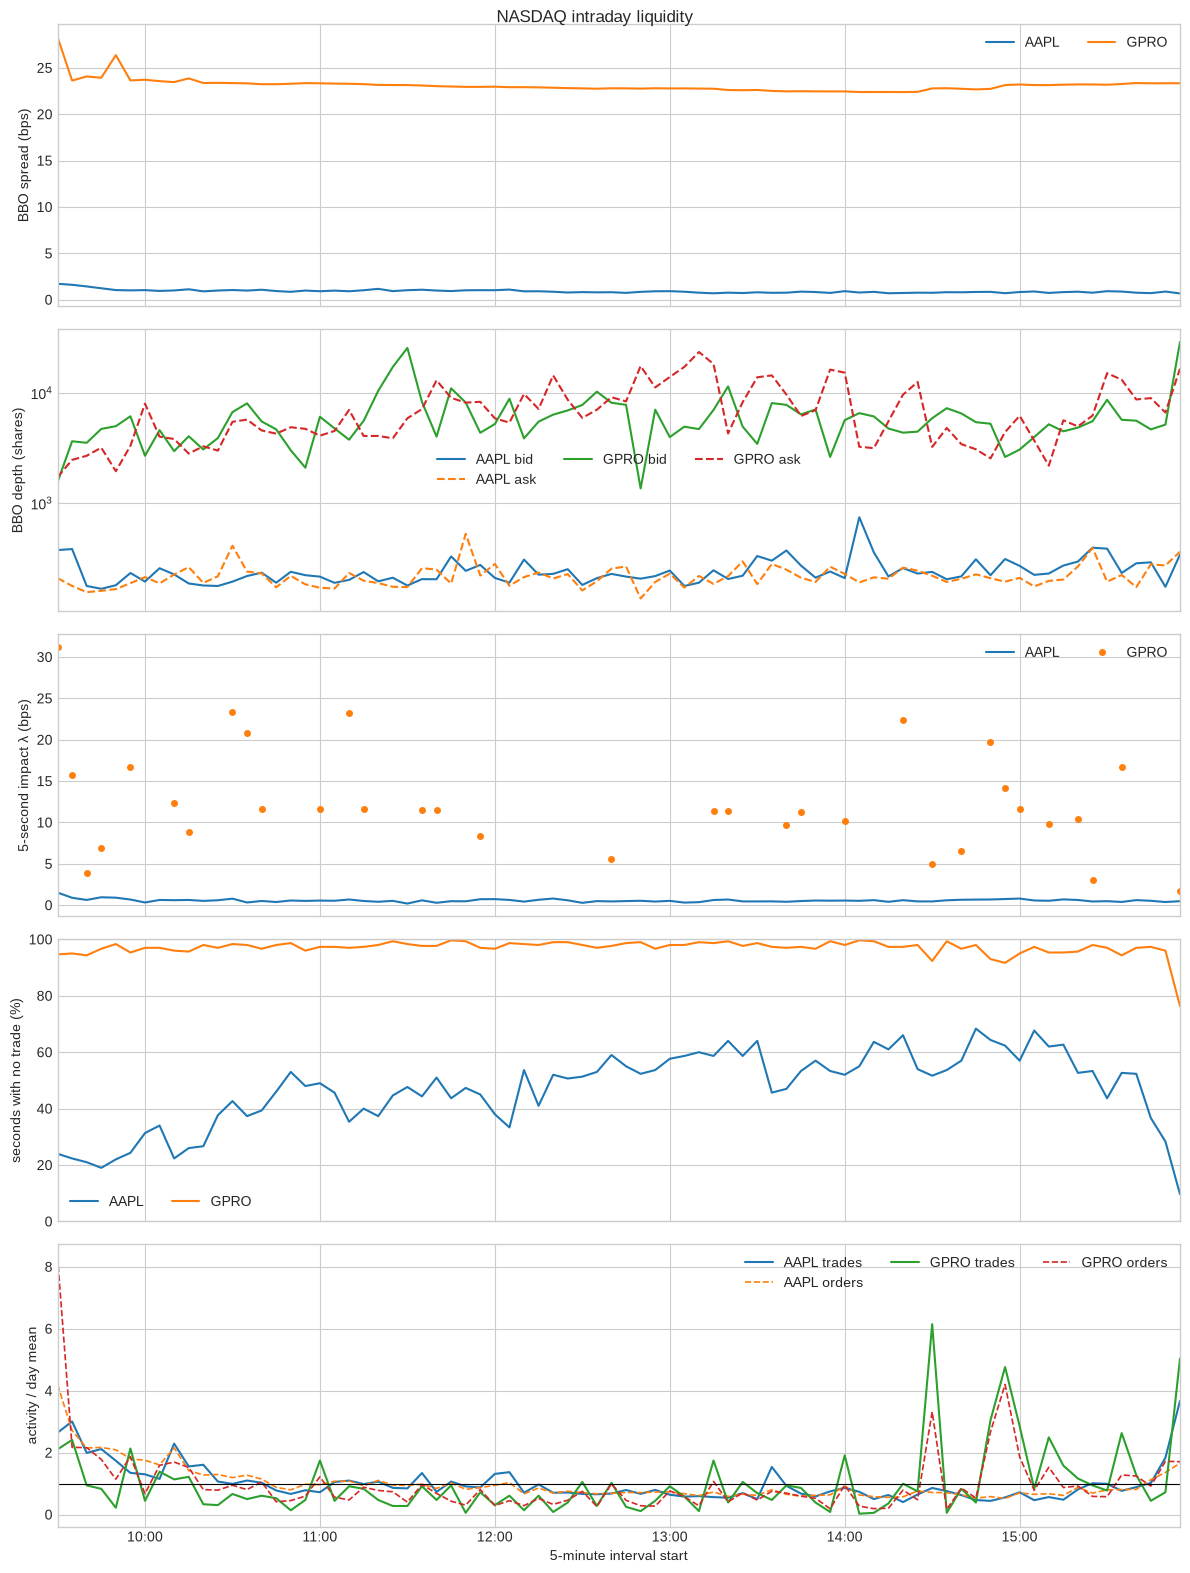

In [12]:
def finish_intraday_axis(ax):
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.set_xlim(FIVE_MIN_GRID[0], FIVE_MIN_GRID[-1])
    ax.legend(frameon=False, ncol=3)


FIVE_MIN_GRID = None


def plot_liquidity_group(names, title, filename, depth_scale=1.0, depth_unit="shares"):
    global FIVE_MIN_GRID
    fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)
    for name in names:
        minute = MINUTES[name]
        five = minute.resample("5min").mean()
        FIVE_MIN_GRID = five.index
        reference_price = five["vwap"].ffill().bfill()
        axes[0].plot(five.index, 10_000 * five["spread"] / reference_price, label=name)
        axes[1].plot(
            five.index, five["bid_depth"] / depth_scale,
            label=f"{name} bid", linewidth=1.5,
        )
        axes[1].plot(
            five.index, five["ask_depth"] / depth_scale,
            label=f"{name} ask", linewidth=1.5, linestyle="--",
        )
        impact = 10_000 * five["price_impact_5s"]
        if impact.notna().mean() < 0.5:
            # Identified in fewer than half the bins: points, not a broken line.
            axes[2].plot(five.index, impact, marker="o", linestyle="none", markersize=4, label=name)
        else:
            axes[2].plot(five.index, impact, label=name)
        axes[3].plot(five.index, 100 * five["no_trade_seconds"] / 60, label=name)
        activity = activity_profile_5min(minute)
        axes[4].plot(activity.index, activity["n_trades"], label=f"{name} trades")
        if "n_orders" in activity:
            axes[4].plot(activity.index, activity["n_orders"], linestyle="--", linewidth=1.2, label=f"{name} orders")
    axes[0].set_ylabel("BBO spread (bps)")
    axes[1].set_ylabel(f"BBO depth ({depth_unit})")
    axes[1].set_yscale("log")
    axes[2].set_ylabel("5-second impact λ (bps)")
    axes[3].set_ylabel("seconds with no trade (%)")
    axes[3].set_ylim(0, 100)
    axes[4].set_ylabel("activity / day mean")
    axes[4].axhline(1.0, color="black", linewidth=0.8)
    axes[4].set_xlabel("5-minute interval start")
    for ax in axes:
        finish_intraday_axis(ax)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()


with time_block("7a. plot_stock_liquidity"):
    plot_liquidity_group(STOCKS, "NASDAQ intraday liquidity", "01_stock_liquidity_5min.png")


**Figure 1 — NASDAQ 5-minute liquidity.** Spreads are in bps of VWAP so the two names can share an axis. GPRO’s line should look almost flat if the penny tick binds; AAPL has more room to move. Depth is log-scaled because AAPL’s share depth is two orders smaller than GPRO’s. The two lower panels add the share of seconds with no trade and trade activity relative to the day mean.

**1. BBO spread.** The object is Best Ask − Best Bid on the NASDAQ book (exchange BBO, not the NBBO):

$$
s_t = a_t - b_t.
$$

The quote is piecewise-constant, so each minute is the exact time-weighted mean — how long the spread sat at each level — not a volume-weighted or last-print mean:

$$
\bar s_{\Delta} = \frac{\sum_i s_i\,\Delta t_i}{\sum_i \Delta t_i},
$$

where $s_i$ is the posted spread on quote update $i$ and $\Delta t_i$ is how long that quote lived inside the minute. The 5-minute bins are the mean of those minutes. The figure reports the relative spread in bps of VWAP so the two names share an axis,

$$
s^{\mathrm{bps}}_{\Delta} = 10^{4}\,\frac{\bar s_{\Delta}}{\mathrm{VWAP}_{\Delta}},
$$

in cents it is 2.6 ct for AAPL and 1.0 ct for GPRO. GPRO’s line is the tick constraint in another unit. $0.01 on a $4.30 name is already ~23 bps, and the minute-level standard deviation is $0.0004, so after the first half-hour the quote is glued to one penny (open-30 mean $0.0106; rest of day, lunch, and last-30 all $0.0100). The open is the only place it lifts — the 5-minute bin starts near 28 bps — then it is visually flat. That is the constraint, not a quiet book. AAPL has room: the same penny is only 0.3 bps on a $290 stock, and the NASDAQ BBO sits at $0.026 on average (~0.9 bps, two-to-three ticks). It opens wider (first 30 minutes $0.038, ~1.3 bps; the very first 5-minute bin is the widest of the day at about 1.7 bps), decays through the first hour, then settles near 0.8–0.9 bps and stays there; the last half-hour is the tightest print of the day ($0.023). There is no separate AAPL spike later in the morning: the one visible bump near 09:50 in the top panel is GPRO's line (a 26 bps bin), not AAPL's.

**2. BBO depth.** When the bid and ask depth lines cross, one side of the touch has become thicker than the other: that is order-book imbalance flipping. A buy hitting the ask, a sell hitting the bid, or a dealer refilling only one side is enough to swap which line sits on top. AAPL weaves almost continuously because both sides live in a tight band of a few hundred shares, so a single refresh changes the sign of the imbalance. GPRO’s crossings have more space between them in shares; the mid-session bid dip is a one-sided hole (bids thin, ask stays posted).

GPRO also spikes much more than AAPL, and that is the expected small-cap pattern, not a plotting artifact. AAPL’s minute bid depth is 248 ± 137 shares (max 1,532). GPRO’s is 6,272 ± 5,318 (max 48,309): the standard deviation is almost as large as the mean. Two mechanical reasons. First, GPRO’s spread is the penny tick, so almost all displayed size sits on one price; one cancel or one print takes a whole level off, and one large resting order puts it back — the book is lumpy. AAPL’s L1 is only a slice of a multi-tick book that is refilled by ~1,800 orders a minute, so depth at the touch stays smooth. Second, GPRO trades a median of 2 times a minute and is silent in 105 minutes, so the quote is not continuously chewed down and rebuilt. The same dollar of liquidity is also ~70× more shares at $4.30 than at $290, which stretches the spikes on this axis. In short: crossings are imbalance; GPRO’s spikes are what a tick-constrained, sparsely traded name is supposed to look like.

**3. Impact.** The bottom panel is a 5-minute mean of a minute-level slope, and that slope is left blank unless the minute has at least five signed trades of both signs. AAPL clears that bar every minute (minimum 50 prints). GPRO does not: 105 minutes have no print at all, the median minute has two trades, and the slope is identified in only 51 of 390 minutes. A 5-minute bin is therefore often empty, or it is the average of one barely identified minute sitting next to four NaNs — that is the broken, disconnected line, not a plotting artifact. When the slope *is* identified it is still noisy. Just clearing five signed prints is a thin regression; one large GPRO print can set the 5-second mid move for the whole minute. The mid itself is coarse: a one-tick move on a $4.30 name is already ~23 bps, so the same mechanical quote update that barely registers on AAPL (0.3 bps per penny at $290) is a tall spike here. Mean identified λ is 0.56 bps for AAPL and 13.3 bps for GPRO (std 10.4 bps, max 42 bps). The open is the one place both names agree: first-30 λ is higher than the rest of the day (AAPL 0.93 vs 0.53 bps; GPRO 18.6 vs 11.6). That is not a U. A U needs a second arm at the close, and this tape does not have one — AAPL stays flat near 0.5 bps, and GPRO’s last identified bursts (around 15:00) do not rebuild. 30 December 2019 is the last full session of the year; the textbook afternoon liquidity drain is something you have to see on the tape.

**4. Missing trades.** The fourth panel is the share of one-second bars in each 5-minute bin with no print. AAPL starts near 20% at the open, climbs to 60–70% through the early afternoon as activity thins, and drops back to about 10% in the closing bin; GPRO is above 90% in almost every bin and reaches 99.7%, i.e. 5-minute windows with a single print. This is the same information as the depth panel read from the other side: GPRO's book is lumpy *because* nobody is hitting it, and every one of those empty seconds is a zero that the 1-second transaction-return series carries as if it were an observation.

**5. Activity.** The fifth panel is trades (solid) and new orders (dashed) per bin, divided by the day mean, so 1.0 is an average bin. AAPL is the textbook U: about 2.4× the rest-of-day trade rate in the first 30 minutes, a trough of 0.7× around 12:00–13:30, and 1.6× in the last 30 minutes, with order arrivals following the same shape (2.9×, 0.7×, 1.1×). GPRO's U is close-heavy (1.5×, 0.5×, 2.0×) and its order flow is even more front-loaded (3.4× at the open). So the intraday U that the return variance only half-shows on this holiday-week session is fully present in activity: the close does come back, in prints and orders, even though it did not in variance.


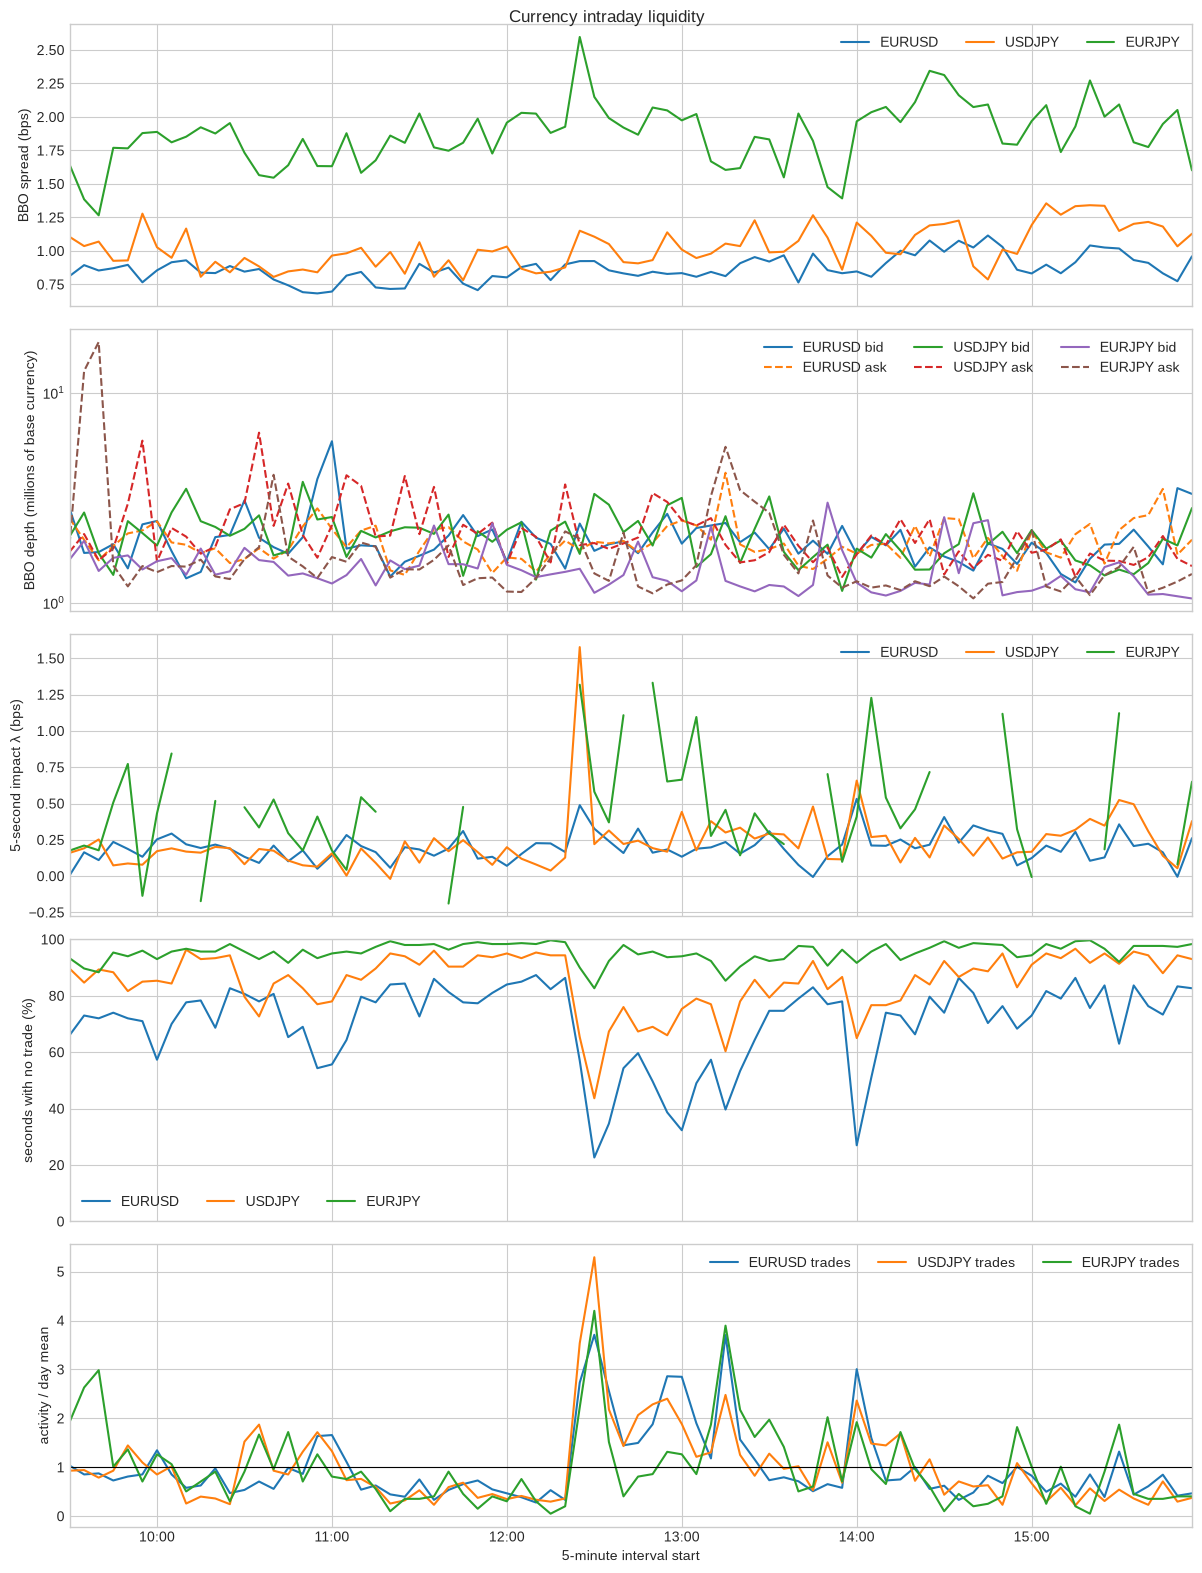

In [13]:
with time_block("7b. plot_fx_liquidity"):
    plot_liquidity_group(
        FX_PAIRS,
        "Currency intraday liquidity",
        "02_currency_liquidity_5min.png",
        depth_scale=1_000_000,
        depth_unit="millions of base currency",
    )


**Figure 2 — FX 5-minute liquidity.** EUR/USD should sit tightest, EUR/JPY widest. Depth is in millions of base currency. The clock is NY 09:30–16:00 on a 2012 London/NY overlap day, so a spread or impact bulge around 12:00–13:30 ET is London close, not a US-equity open effect. If EUR/JPY impact is sparse, that matches the 103 identified minutes in the summary table.

**Missing trades and activity in FX.** The fourth panel says how sparse even the majors are at one second: EUR/USD has no print in about 70% of seconds, USD/JPY 85%, EUR/JPY 95%. The fifth panel is not a U. All three pairs peak between 12:00 and 13:30 ET — 2.2× the rest-of-day trade rate for EUR/USD, 2.1× for USD/JPY, 1.5× for EUR/JPY — and fade into the last 30 minutes (0.4–0.7×). That is the London close arriving in New York time; the 09:30 open is simply mid-session for the dollar pairs. EUR/JPY alone is busier in the first 30 minutes (1.9×), consistent with the arbitrage seconds clustering at 09:34–09:43.


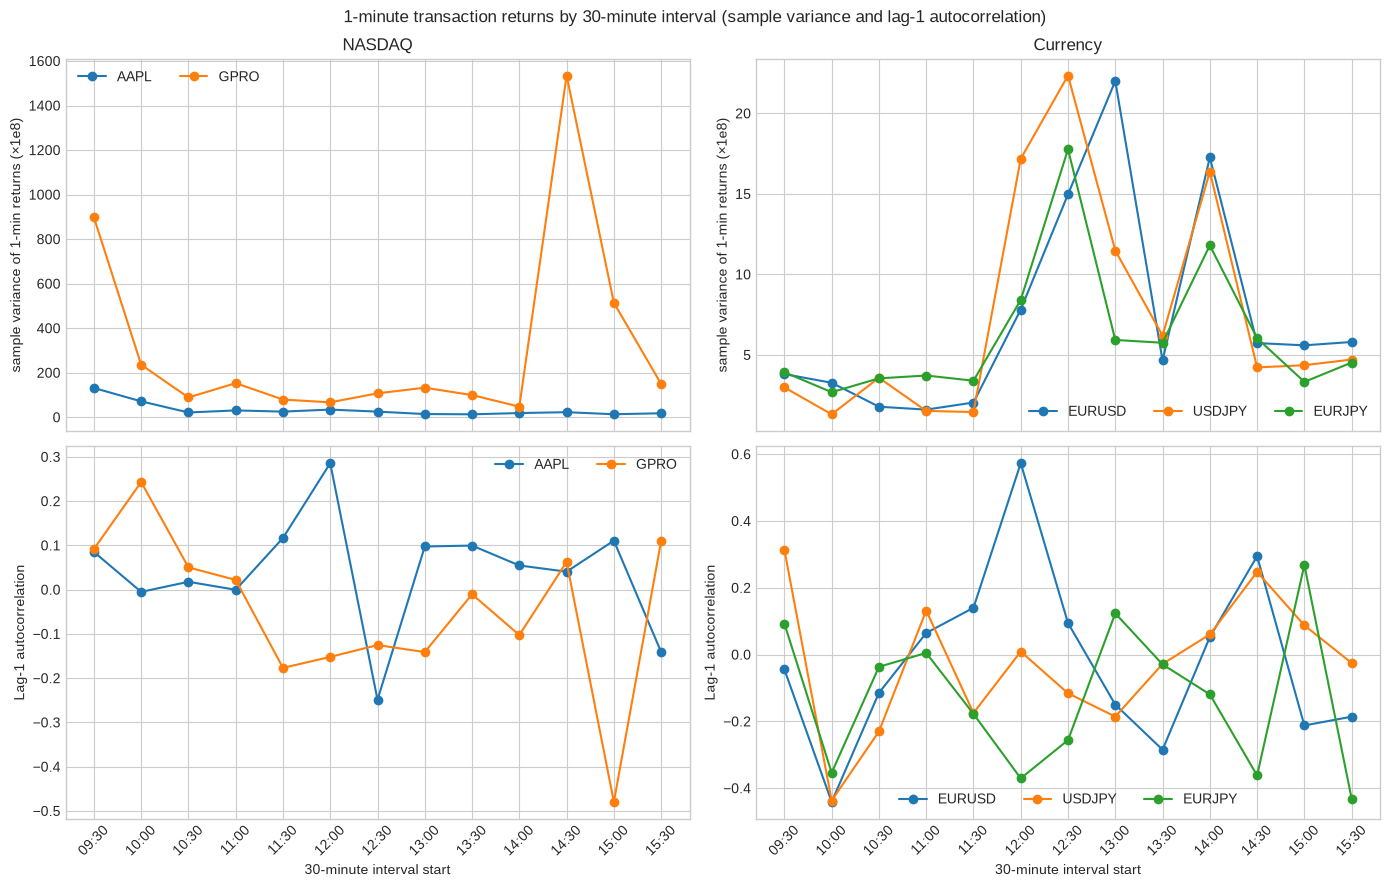

In [14]:
with time_block("7c. plot_30min_variance_acf"):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex="col")
    for column, (market, names) in enumerate((("NASDAQ", STOCKS), ("Currency", FX_PAIRS))):
        for name in names:
            diagnostic = TX_30MIN.loc[name]
            labels = [f"{t:%H:%M}" for t in diagnostic.index]
            axes[0, column].plot(
                labels, diagnostic["variance"] * 1e8, marker="o", label=name
            )
            axes[1, column].plot(
                labels, diagnostic["autocorr_lag1"], marker="o", label=name
            )
        axes[0, column].set_title(market)
        axes[0, column].set_ylabel("sample variance of 1-min returns (×1e8)")
        axes[1, column].set_ylabel("Lag-1 autocorrelation")
        axes[1, column].set_xlabel("30-minute interval start")
        for row in range(2):
            axes[row, column].tick_params(axis="x", rotation=45)
            axes[row, column].legend(frameon=False, ncol=3)
    fig.suptitle("1-minute transaction returns by 30-minute interval (sample variance and lag-1 autocorrelation)")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "03_transaction_return_30min.png", dpi=180, bbox_inches="tight")
    plt.show()


**Figure 3 — 30-minute transaction-return sample variance and lag-1 ACF.** Left column is NASDAQ, right column is FX. AAPL should peak at 09:30 and stay quiet into the close on this holiday-week Monday. GPRO’s 14:30 spike is the panel to talk about; it is larger than the open. FX variance should rise into 12:00–13:30, not at 09:30. The ACF panels use ~30 one-minute returns per point, so individual dots wander. The useful contrast is the *level* of variance across the day, not any one autocorrelation.


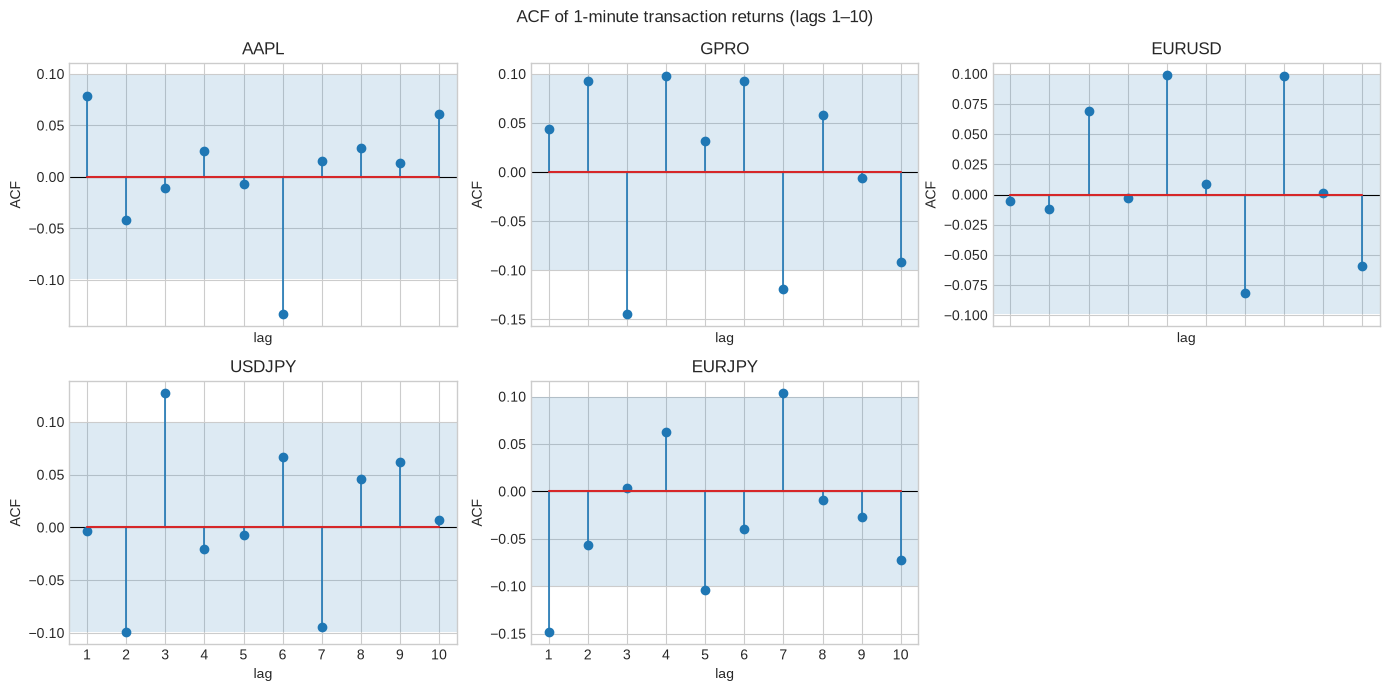

In [15]:
with time_block("7d. plot_transaction_acf"):
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
    axes = axes.ravel()
    for ax, name in zip(axes, ALL_DATA):
        returns = PRICE_SERIES[(name, "1min")]["trade_ret"].dropna()
        acf_values = autocorrelations(returns, lags=10).iloc[1:]  # drop lag 0 (= 1 by construction)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.axhspan(-1.96 / np.sqrt(len(returns)), 1.96 / np.sqrt(len(returns)), alpha=0.15)
        markerline, stemlines, baseline = ax.stem(acf_values.index, acf_values.values)
        plt.setp(stemlines, linewidth=1.2)
        ax.set_title(name)
        ax.set_xlabel("lag")
        ax.set_xticks(range(1, 11))
        ax.set_ylabel("ACF")
    axes[-1].axis("off")
    fig.suptitle("ACF of 1-minute transaction returns (lags 1–10)")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "04_transaction_return_acf.png", dpi=180, bbox_inches="tight")
    plt.show()


**Figure 4 — 10-lag ACF of 1-minute transaction returns.** Lag 0 equals 1 by construction and is dropped from the plot, as suggested in the discussion session, so the axis starts at lag 1. The shaded band is the usual ±1.96/√T noise range. EUR/JPY is the panel that leaves the band at lag 1 (about −0.15). AAPL is mildly positive. The two dollar pairs sit near zero. After lag 2–3 the stems are mostly inside the band, which is why 10 lags is enough: the series has already become noise.


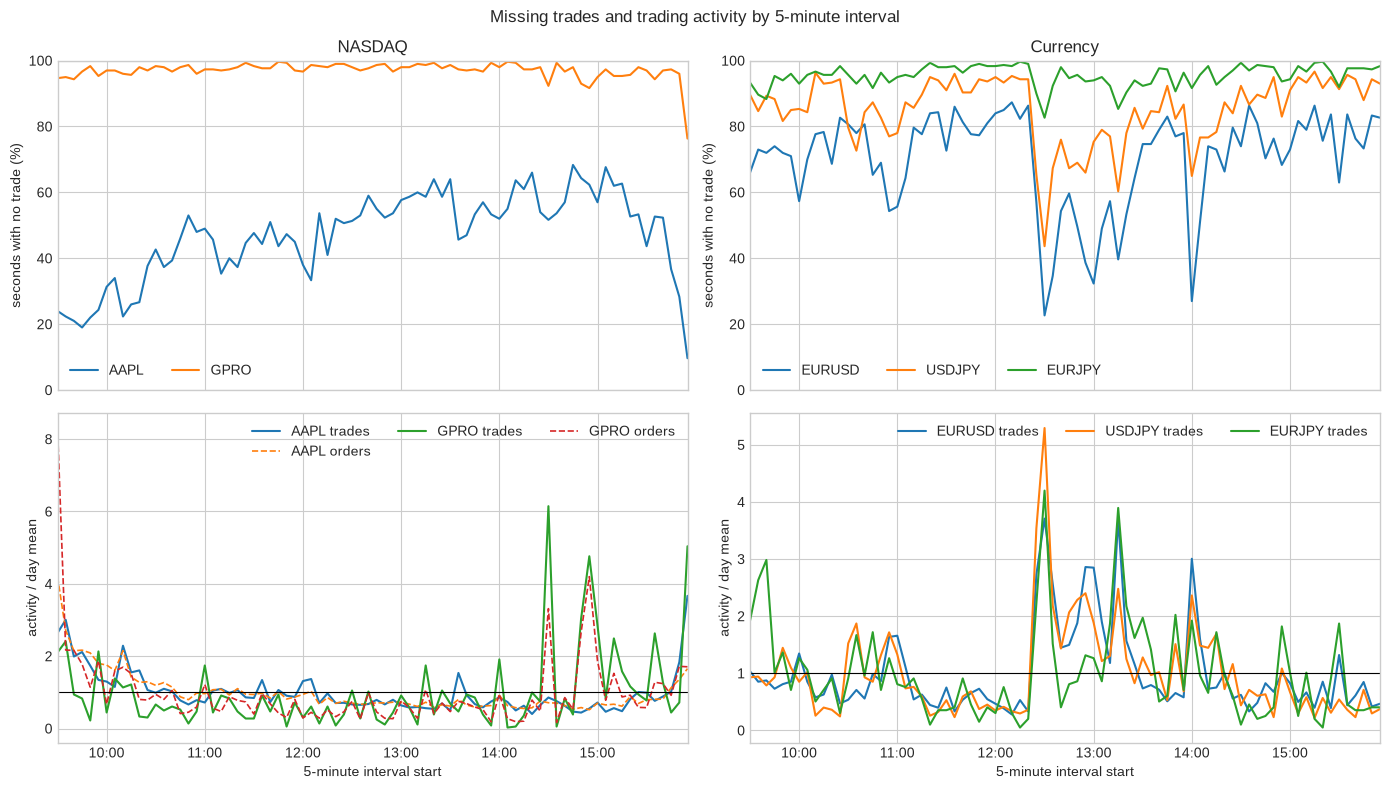

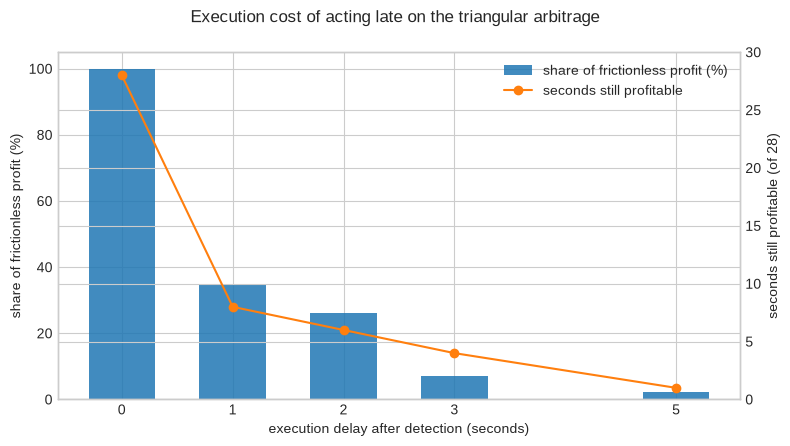

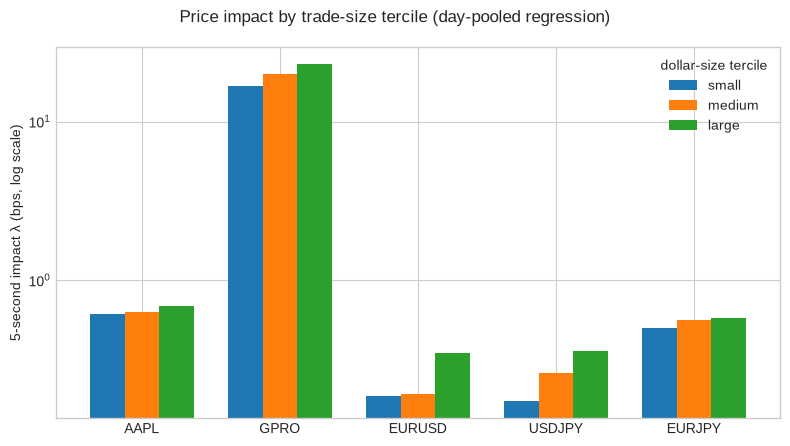

In [16]:
# Appendix figures for the report: missing trades and activity (A1), the
# execution cost of acting late on the arbitrage (A2), impact by trade size (A3).
with time_block("7e. plot_appendix_missing_trades_activity"):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex="col")  # stocks and FX are on different dates
    for col, (market, names) in enumerate((("NASDAQ", STOCKS), ("Currency", FX_PAIRS))):
        for name in names:
            minute = MINUTES[name]
            five = minute.resample("5min").mean()
            axes[0, col].plot(five.index, 100 * five["no_trade_seconds"] / 60, label=name)
            activity = activity_profile_5min(minute)
            axes[1, col].plot(activity.index, activity["n_trades"], label=f"{name} trades")
            if "n_orders" in activity:
                axes[1, col].plot(activity.index, activity["n_orders"], linestyle="--", linewidth=1.2, label=f"{name} orders")
        FIVE_MIN_GRID = five.index  # x-limits for this market's date
        axes[0, col].set_title(market)
        axes[0, col].set_ylim(0, 100)
        axes[0, col].set_ylabel("seconds with no trade (%)")
        axes[1, col].axhline(1.0, color="black", linewidth=0.8)
        axes[1, col].set_ylabel("activity / day mean")
        axes[1, col].set_xlabel("5-minute interval start")
        for row in range(2):
            finish_intraday_axis(axes[row, col])
    fig.suptitle("Missing trades and trading activity by 5-minute interval")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "A1_missing_trades_activity_5min.png", dpi=180, bbox_inches="tight")
    plt.show()

with time_block("7f. plot_appendix_execution_decay"):
    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    decay = ARBITRAGE_DECAY
    ax1.bar(decay.index, 100 * decay["share_of_frictionless_profit"], width=0.6, alpha=0.85, label="share of frictionless profit (%)")
    ax1.set_xlabel("execution delay after detection (seconds)")
    ax1.set_ylabel("share of frictionless profit (%)")
    ax1.set_ylim(0, 105)
    ax1.set_xticks(list(decay.index))
    ax2 = ax1.twinx()
    ax2.plot(decay.index, decay["seconds_still_profitable"], color="tab:orange", marker="o", label="seconds still profitable")
    ax2.set_ylabel(f"seconds still profitable (of {int(ARBITRAGE_STATS['seconds_with_arb'])})")
    ax2.set_ylim(0, 30)
    handles = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax1.legend(handles, labels, frameon=False, loc="upper right")
    fig.suptitle("Execution cost of acting late on the triangular arbitrage")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "A2_arbitrage_execution_decay.png", dpi=180, bbox_inches="tight")
    plt.show()

with time_block("7g. plot_appendix_impact_by_size"):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    lam = IMPACT_BY_SIZE["lambda_bps"].unstack("tercile")[["small", "medium", "large"]].loc[list(ALL_DATA)]
    lam.plot(kind="bar", ax=ax, width=0.75)
    ax.set_yscale("log")
    ax.set_ylabel("5-second impact λ (bps, log scale)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="dollar-size tercile", frameon=False)
    fig.suptitle("Price impact by trade-size tercile (day-pooled regression)")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "A3_impact_by_trade_size.png", dpi=180, bbox_inches="tight")
    plt.show()


## Observations for the report

These notes stay with the tables and figures above. The later PDF should reuse them rather than invent a smoother story.

**Price impact is positive, and larger trades carry more of it.** Every day-mean λ is positive, a signed buy moves the next 5-second midpoint up, as the slides expect. Across dollar-size terciles the slope rises monotonically on all five books (AAPL 0.61 → 0.69 bps, GPRO 16.8 → 23.1 bps, EUR/USD 0.19 → 0.35 bps, USD/JPY 0.17 → 0.36 bps, EUR/JPY 0.50 → 0.58 bps): the larger the print, the more information the market reads into it.

**Missing trades.** The share of one-second bars with no print (47% AAPL, 70% EUR/USD, 85% USD/JPY, 95% EUR/JPY, 97% GPRO) ranks the five books exactly as relative spread does and is worth reporting as a liquidity measure in its own right: it is the zero-return illiquidity proxy read intraday, it is what makes GPRO's L1 depth lumpy, and it is what the one-second transaction-return statistics are mostly made of.

**AAPL vs. GPRO.** AAPL prints about $4.4M per minute on average (median $3.2M). GPRO prints about $9.7k (median $433). That 450× gap is the reason we picked them: same code, two very different books. AAPL’s mean NASDAQ BBO spread is $0.026 on a ~$290 stock (about 0.9 bps). GPRO’s is $0.010 on a ~$4.34 stock (about 23 bps). GPRO’s spread standard deviation is $0.0004, so the penny tick is binding almost all day. Mean 5-second impact is 0.56 bps for AAPL and 13.3 bps for GPRO. Share depth lies: GPRO shows ~6,300 shares at the bid versus AAPL’s ~250, but in dollars AAPL is deeper (~$72k vs ~$27k). These are NASDAQ BBO numbers, not the NBBO. A protected National Best Bid/Offer can be tighter than NASDAQ alone; we do not have the other venues.

**Why depth at twice the average spread.** The assignment asks for it because the BBO size is only the first step of a walk. The 2× band is the size you can lift or hit before paying more than two typical spreads. On this tape the ratio is the result, not a formality. AAPL’s 2× bid depth is about 5× its L1 bid (1,298 vs 248 shares); the ask side is about 6×. GPRO’s 2× band is only about 2× L1, because its average spread *is* the tick, so `mid ± 2×spread` barely reaches the next penny. FX books sit the other way: EUR/USD 2× depth is about 11× L1. The measure is doing different work on a multi-tick large-cap than on a penny-constrained small-cap.

**Are spreads wider at the open, and do spread and depth move against each other?** Read the liquidity-diagnostics table. The lecture default is a morning-wide, lunch-tight U and a negative spread–depth correlation. GPRO cannot produce much of a spread U: the tick already binds. AAPL has more room ($0.026 mean, $0.006 std). FX should not be forced into a US-equity open story; 25 January 2012 is a London/NY overlap day. If the table shows a weak or positive spread–depth correlation, that is a finding for this day, not a coding error.

**Is the 5-second impact permanent?** The slope is the signed mid move from the trade to five seconds later. Permanent information should leave later midquote autocorrelations near zero or slightly positive. Temporary bounce should flip them negative. AAPL’s 1-minute mid ACF is +0.105, so the 5-second move is not being walked back at the next minute — if anything the flow continues. GPRO’s mid ACF is +0.015, and the slope itself is identified in only 51 of 390 minutes, so we should not claim a clean permanence result there. EUR/JPY’s 1-minute mid ACF is −0.177: that cross *does* mean-revert at a minute, which is closer to temporary dislocation than to a permanent information shock.

**Currency.** EUR/USD (~0.87 bps) and USD/JPY (~1.03 bps) are tighter than EUR/JPY (~1.87 bps). The cross is the synthetic residual of the other two legs, so its own book is a little wider. All three FX pairs are still one to two orders of magnitude tighter than either stock.

**Triangular arbitrage.** Twenty episodes, 28 seconds, 0.12% of the day. Mean length 1.4s, longest 6s, mean 0.19 bps, max 1.18 bps, binding size about €1.3M, which is one level-one clip against a book of roughly €2M at the touch. Frictionless marked P&L if every second were taken is $678 — an upper bound, not cash. Only 13 of the 28 seconds clear one tick of the coarsest leg (0.13 bps) and one clears a full EUR/USD pip. Acting one second late keeps 35% of the $678 and turns the average loop return negative (−0.60 bps); after three seconds 7% is left. The opportunity's half-life is under a second, and that, not the detector's microseconds, is the execution constraint. Almost every printed second is loop A (sell EUR/USD and USD/JPY, buy EUR/JPY); only three seconds are loop B. The seconds cluster in two windows, 09:34–09:43 and 13:15–14:18. The afternoon cluster sits on top of the FX variance peak (London close, 12:00–13:30 ET), which is a better story for this tape than “arbs appear at the NY open.”

**Autocorrelation.** On the full one-second grid the lag-1 ACFs look small (|ρ| < 0.07), but that grid is 47–97% forward-filled zeros, so the number is diluted, not informative. On the trade-to-trade series the dollar pairs show the negative lag-1 signature of bid–ask bounce (EUR/USD −0.076, USD/JPY −0.039) and GPRO shows positive persistence (+0.131); AAPL is +0.037 either way. At one minute the interesting object is EUR/JPY (trade −0.149, mid −0.177). The transaction number carries some bounce, but the *midquote* number cannot — a midquote has no side to alternate between — so what the cross is showing is quote overshoot and correction on a thin book where one minute in five has no print. That is not a general FX fact: EUR/USD and USD/JPY sit near zero at the same horizon. AAPL’s mild positive 1-minute mid ACF is order-flow persistence, not bid–ask alternation. Beyond lag 2–3 every series is inside the noise band, so there is no time-series momentum to forecast with at these horizons.

**Variance and liquidity.** Across 30-minute windows the return variance rises with spread and impact and falls with depth, and tracks the trade count almost one-for-one (correlations 0.8–0.9 for AAPL and GPRO): volatile half-hours are the expensive, thin, busy ones. Autocorrelations show no consistent relation with liquidity at this sample size.

**Intraday variance and activity.** AAPL’s opening half hour is the loudest bin (1.31e-6) and lunch is quiet (about 1.3e-7). The close does **not** come back up in variance — but it does in activity: AAPL prints 1.6× and GPRO 2.0× the rest-of-day trade rate in the last 30 minutes, against 0.7× and 0.5× at lunch, so the U-shape is fully there in trades and orders and only half there in variance. 30 December 2019 is the Monday of a short New Year week; a missing afternoon U is a holiday-week observation, not a rejection of the textbook shape. GPRO’s largest variance bin is 14:30–15:00 (1.53e-5), bigger than the open, and the next bin’s lag-1 ACF is −0.48. That is a GPRO-specific afternoon, not a U. FX variance peaks at 12:00–13:30 ET — London close — the opposite clock of the US-equity open.

**Theory, only as far as the tape goes.** AAPL vs GPRO still matches the Glosten–Milgrom / Kyle reading: impact and relative spread are larger where a dealer has less uninformed flow to average against. The rest of the day does not. GPRO’s spread is a tick, not an information U. FX variance is a London-close event. Apparent triangles last about a second and sit in the same afternoon window as the FX variance spike. Those are the observations the report should keep.

Numbers come from the CSVs under `outputs/`. Re-check them if the pipeline or files change.


In [17]:
TIMING_BARS.setdefault("7a. plot_stock_liquidity", SESSION_BARS * len(STOCKS))
TIMING_BARS.setdefault("7b. plot_fx_liquidity", SESSION_BARS * len(FX_PAIRS))
TIMING_BARS.setdefault("7c. plot_30min_variance_acf", SESSION_BARS * len(ALL_DATA))
TIMING_BARS.setdefault("7d. plot_transaction_acf", SESSION_BARS * len(ALL_DATA))
TIMING_TABLE = timing_table(TIMINGS, TIMING_BARS)
TIMING_TABLE.to_csv(OUTPUT_DIR / "timings.csv")
display(TIMING_TABLE.round(4))
print(f"Total timed wall clock: {TIMING_TABLE['seconds'].sum():.3f}s")
print(
    f"Loads: {TIMINGS['1. load_databento_stocks']:.1f}s for {len(STOCKS)} NASDAQ books, "
    f"{TIMINGS['2. load_currency_data']:.1f}s for {len(FX_PAIRS)} EBS books "
    f"({TIMING_TABLE.loc['2. load_currency_data', 'tape_s_per_compute_s']:,.0f} tape seconds per compute second)."
)
print(
    f"Arbitrage: batch scan {TIMINGS['6. triangular_arbitrage']*1e3:.1f} ms for {SESSION_BARS:,} seconds; "
    f"incremental loop median {ARBITRAGE_LATENCY['median_us']:.2f} µs, p99 {ARBITRAGE_LATENCY['p99_us']:.2f} µs, "
    f"max {ARBITRAGE_LATENCY['max_us']:.0f} µs per decision. "
    f"Mean episode length {float(ARBITRAGE_STATS['mean_duration_s']):.1f}s (max {float(ARBITRAGE_STATS['max_duration_s']):.0f}s); "
    f"{100*ARBITRAGE_DECAY.loc[1, 'share_of_frictionless_profit']:.0f}% of the frictionless profit survives a 1-second delay."
)


,seconds,bars_1s,tape_s_per_compute_s,us_per_bar
step,,,,
1. load_databento_stocks,25.830400,"46,800.000000","1,811.821600",551.930700
2. load_currency_data,8.901200,"70,200.000000","7,886.596900",126.797400
3. minute_stats_all_instruments,0.496400,"117,000.000000","235,686.574500",4.242900
3b. impact_by_trade_size,0.090500,NaN,NaN,NaN
4. price_series_returns_acf,0.220500,"117,000.000000","530,564.972900",1.884800
5. transaction_diagnostics_30min,0.080500,"117,000.000000","1,452,780.787600",0.688300
6. triangular_arbitrage,0.051900,"23,400.000000","450,450.884000",2.220000
6b. arbitrage_execution_decay,0.083400,NaN,NaN,NaN
6c. triangular_arbitrage_incremental,0.028100,"23,400.000000","833,201.854800",1.200200


Total timed wall clock: 44.245s
Loads: 25.8s for 2 NASDAQ books, 8.9s for 3 EBS books (7,887 tape seconds per compute second).
Arbitrage: batch scan 51.9 ms for 23,400 seconds; incremental loop median 0.42 µs, p99 1.14 µs, max 64 µs per decision. Mean episode length 1.4s (max 6s); 35% of the frictionless profit survives a 1-second delay.


## Function timing versus the length of an opportunity

The transcript's test is blunt: if the arbitrage lasts two seconds and the code takes five, you are late. The table above answers it in three different units, and the answer is different for each part of the pipeline.

**Where the clock goes.** Reading the tape dominates: 25.8 s for the two NASDAQ books (MBP-10 streamed twice plus one MBO pass, 552 µs per one-second bar) and 8.9 s for the three EBS books (127 µs per bar). Everything analytical is sub-second: the per-minute table 0.50 s, the return series and ACFs 0.22 s, the 30-minute diagnostics 0.08 s, and the batch arbitrage scan 52 ms for 23,400 seconds (2.2 µs per bar). The four main figures cost 6.1 s together and the three appendix figures 2.3 s. The whole notebook runs end to end in about a minute.

**Before and after.** The previous committed run took 347.9 s, of which 238.9 s was the currency loader and 100.1 s the stock loader. The currency loader replayed each 10-level EBS ladder *twice*, once to learn the day's average spread and once to measure depth inside the 2×-spread band, in a per-timestamp Python loop; rewriting it as a single replay that snapshots the ladder and computes the band vectorised afterwards took it from 224 s to 8 s on the same machine with bit-identical outputs. The stock loader still streams the MBP-10 file twice for the same reason; removing the second pass would mean holding roughly 180 MB of level data for AAPL alone, and the pass costs about 9 s, so we kept it and say so. Timing is what made the choice visible: half the original runtime was recomputation.

**Could it keep up with a live feed?** Expressed as tape seconds per compute second, the currency loader processes 7,887 seconds of market time per second of wall clock and the stock loader 1,812 so both are three orders of magnitude inside real time even in Python — but that is a batch number for a whole session read from a file, not a latency. The number that matters for the arbitrage is the cost of one decision. Run one second at a time, as a live loop would, with the wall clock read around every evaluation, the triangle check costs a median of 0.42 µs, a 99th percentile of 1.14 µs and a worst case of 64 µs per second (12 ms for the whole session). The opportunities last 1.4 s on average and 6 s at most, so detection is five to six orders of magnitude inside the window. The lecture's “2-second arbitrage, 5-second code” failure does not happen here.

**What actually binds.** The execution-decay table is the constraint the timing table cannot show: re-pricing every flagged second one second later keeps 8 of 28 seconds profitable and 35% of the frictionless $678, and turns the average loop return negative (−0.60 bps); after three seconds 7% is left. So the strategy's clock is not our detector, it is the round trip of three aggressive orders to EBS and back, plus last-look and fees that these files do not carry. Only 13 of the 28 seconds clear one tick of the coarsest leg and one clears a full pip, so even the frictionless number is mostly grid rounding. Timing the Python is necessary — it is how we found the redundant pass — but for this strategy the honest statement is that a sub-microsecond detector is chasing a sub-second opportunity whose profit is gone before a reasonable order could arrive.
